s0 = 0.00014880743994372128
t0 = 4.963681906358074e-13
20*t0 [ps] = 9.927363812716147
N = 158838
N_conv = 160001
dt [fs] = 5.0

Bunch weights:
sigma = 0.2 mm : weight = 1.0000e+00
Loaded CST file: /home/kim/PCWR/data/ss_p02_cpw13p99.txt
Detected s-unit: mm
Conversion: 1 mm = 0.001 m

--- Synthetic reconstruction 1 ---

Global scale = 30441802222.64186
sigma = 0.2 mm | scale = 1.0000e+00 | sigma_head = 2.0000e-03 | sigma_tail = 1.0000e-03
CG info: 500

--- CST reconstruction ---

Global scale = 30138991495.212337
sigma = 0.2 mm | scale = 1.0000e+00 | sigma_head = 2.0000e-03 | sigma_tail = 1.0000e-03
CG info: 500

--- Wake to impedance: reconstructed synthetic, no zero padding ---
* FFT mode = positive causal branch, no extra time padding
* Positive-time wake samples = 79419
* FFT samples = 2*(Nt-1) = 158836
* Number of frequency samples = 79419
* Maximum frequency = 1.000000e+14 Hz
* Frequency resolution = 1.259160e+09 Hz
* Time step used for FFT = 5.000000e-15 s
* Relativistic beta = 1

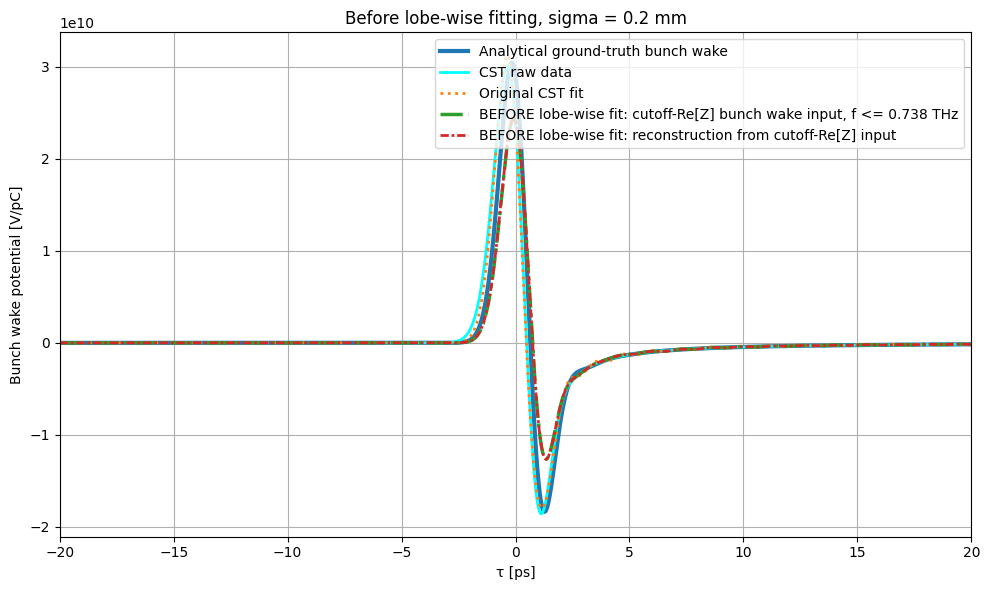


--- Lobe-wise constant time-domain fit: cutoff bunch wake -> cyan CST bunch wake ---
* Lobe-wise constant CST bunch-wake fit
* Fit space = bunch-wake time domain
* Model  = cutoff/max-envelope bunch wake before fitting
* Target = CST bunch wake interpolated on solver grid
* Fit window = [-50.0, 50.0] ps
* Active thresholds: target=0.0200, model=0.0050
* Peak threshold for lobe detection = 0.0300
* Relative error before lobe fit = 4.351782e-01
* Relative error after lobe fit  = 4.048377e-01
  - Bunch 0: active samples = 5069, lobes = 3
      lobe 00: [-2.245, 0.745] ps, scale = 1.154368e+00, err 4.456e-01 -> 4.290e-01
      lobe 01: [0.745, 6.095] ps, scale = 1.342511e+00, err 4.066e-01 -> 3.274e-01
      lobe 02: [6.095, 24.420] ps, scale = 9.896291e-01, err 5.699e-02 -> 5.602e-02


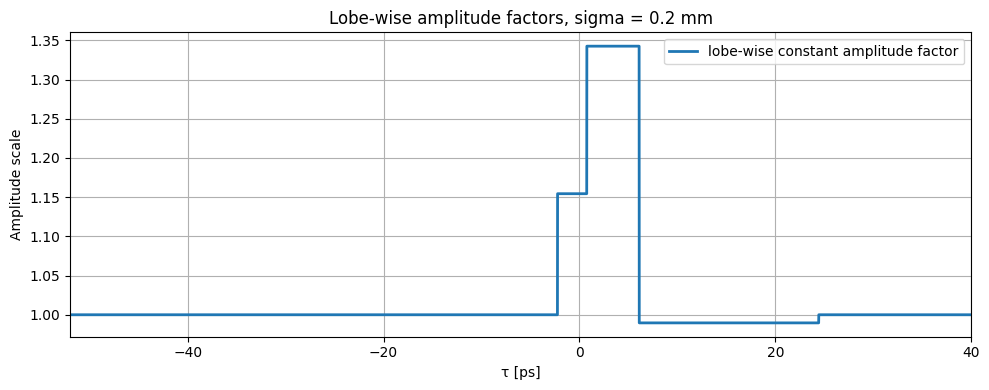


--- Reconstruction using lobe-wise fitted cutoff bunch wake as solver input ---

Global scale = 28138386316.14225
sigma = 0.2 mm | scale = 1.0000e+00 | sigma_head = 2.0000e-03 | sigma_tail = 1.0000e-03
CG info: 500

--- Wake to impedance: final reconstruction from lobe-wise fitted cutoff bunch-wake CST input ---
* FFT mode = positive causal branch, no extra time padding
* Positive-time wake samples = 79419
* FFT samples = 2*(Nt-1) = 158836
* Number of frequency samples = 79419
* Maximum frequency = 1.000000e+14 Hz
* Frequency resolution = 1.259160e+09 Hz
* Time step used for FFT = 5.000000e-15 s
* Relativistic beta = 1.0

--- Final Re[Z]: local upper-envelope passivity bridge ---
* Local upper-envelope passivity bridge for multi-hump Re[Z]
* Positive samples are never lowered
* Negative valleys/ripple dips are filled by local positive bridges
* Terminal negative intervals are set to zero only; no long tail bridge
* Negative components = 35
* Negative samples = 40209 / 79419
  - negati

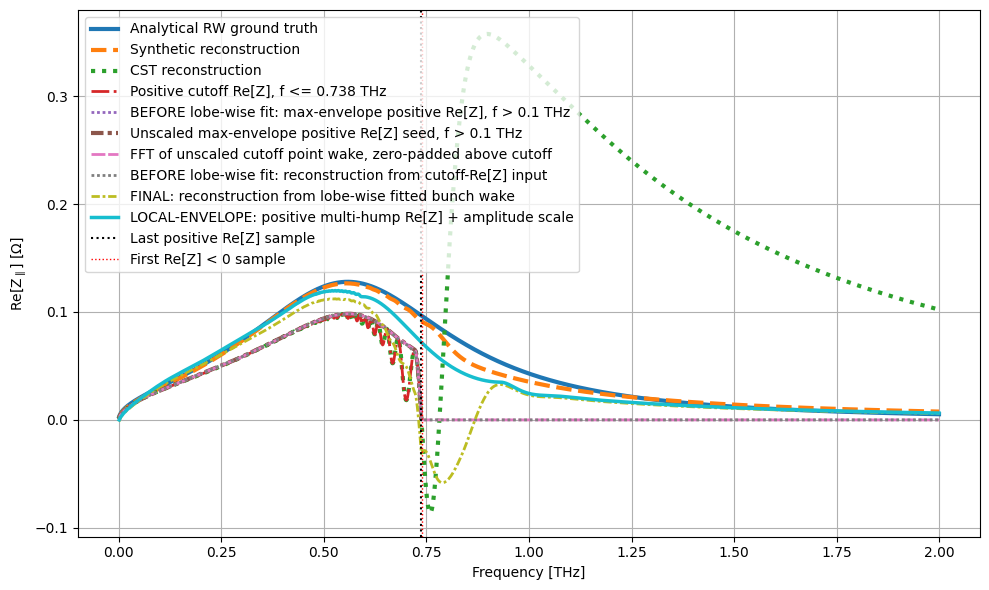

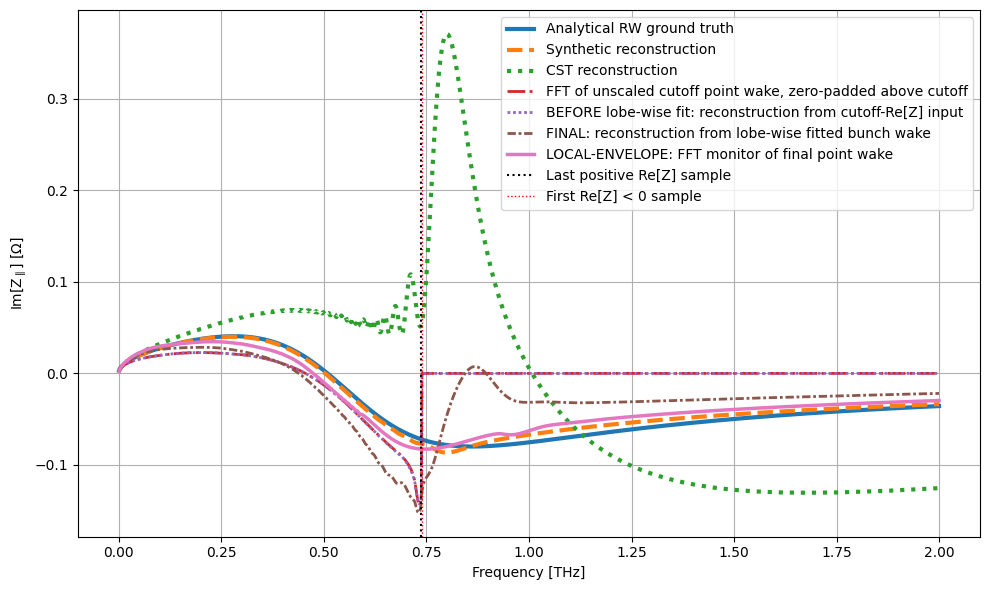

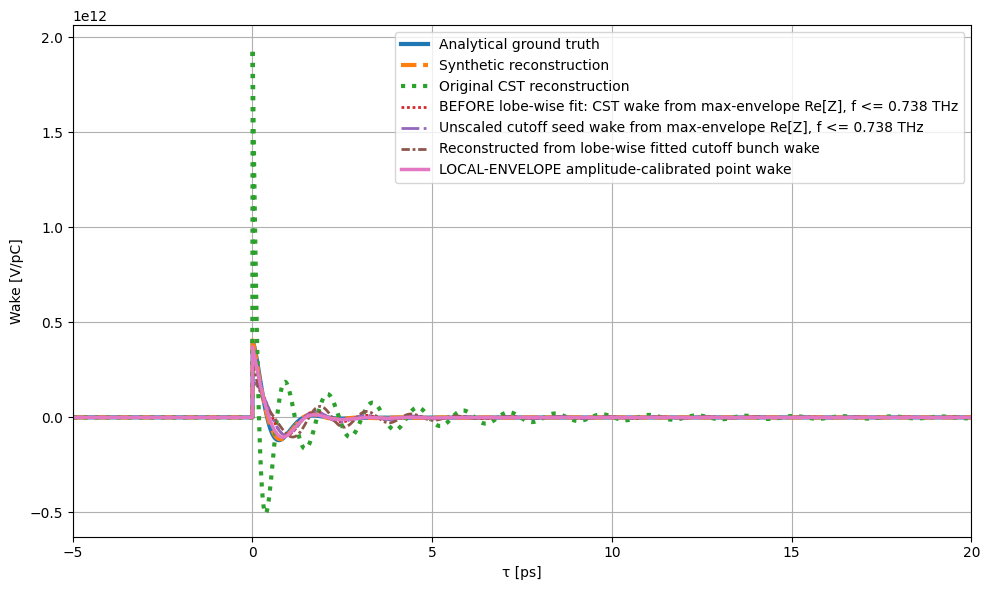

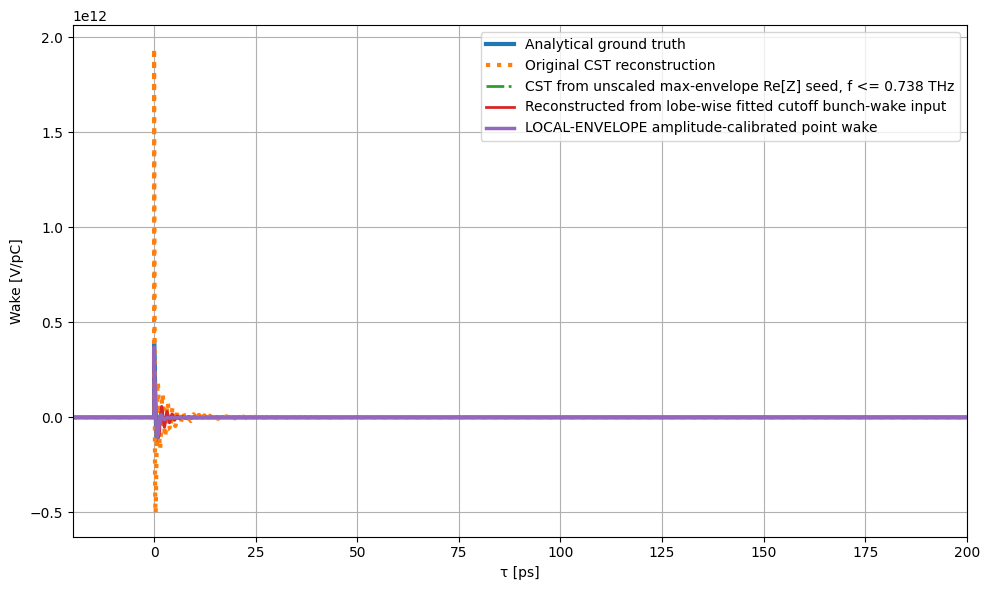

Loaded CST file: /home/kim/PCWR/data/ss_p02_cpw13p99.txt
Detected s-unit: mm
Conversion: 1 mm = 0.001 m


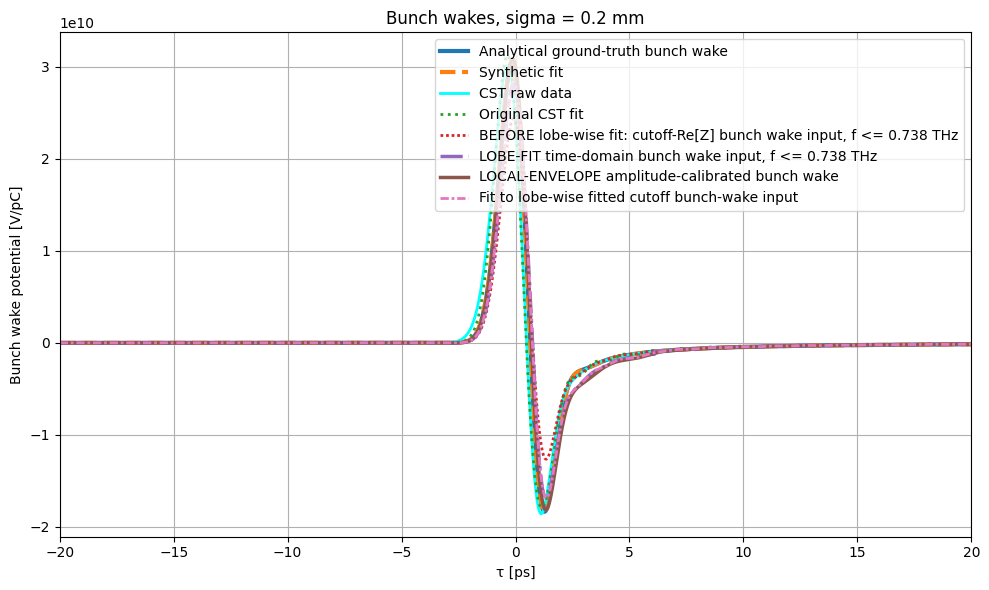

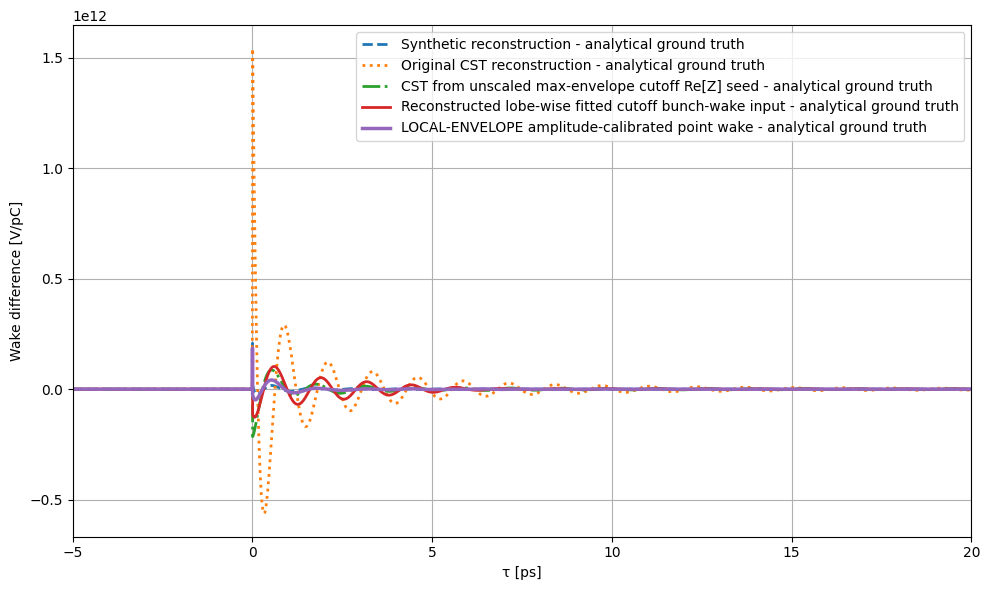


=== Peak-to-peak bridged multi-hump Re[Z] summary ===
Cutoff sample kept: 0.737868 THz
First negative Re[Z] sample: 0.739127 THz
Estimated zero crossing: 0.737904 THz
Number of positive-Re[Z] samples kept before zero padding: 587 / 79419
Zero-padded max-envelope one-sided frequency grid length used for IFFT: 79419
Original positive-time samples: 79419
Recovered wake samples before interpolation: 79419
Monitoring FFT of unscaled cutoff point wake: no time zero padding, high frequencies zero-padded after cutoff
Monitoring FFT frequency samples: 79419
Fit method: lobe-wise constant amplitude factors in bunch-wake time domain
Post-processing main time half-window: ±50.000 ps
Lobe-wise fit window: [-50.0, 50.0] ps
Lobe-wise target active threshold: 0.0200
Lobe-wise model active threshold: 0.0050
Lobe detection peak threshold: 0.0300
Relative CST bunch-wake error before lobe-wise fit: 4.351782e-01
Relative CST bunch-wake error after lobe-wise fit:  4.048377e-01
Final Re[Z] construction: loc

In [8]:
# combine
# Hybrid cutoff + lobe-wise high-frequency recovery version

# time grid weighting + short-bunch weighting

# Point-Charge Wake Reconstruction

import numpy as np
import re
from pathlib import Path
from scipy.special import iv, ive
from scipy.signal import fftconvolve, find_peaks
from scipy.sparse.linalg import LinearOperator, cg
from scipy.constants import c, physical_constants
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.special import wofz
import matplotlib.pyplot as plt

# =================================================
# CONSTANTS
# =================================================

c_light = c
Z0 = physical_constants["characteristic impedance of vacuum"][0]

L = 0.01
b = 30e-3
cond = 1.45e6 #5.8e7 #1.45e6

# Characteristic length of RW
s0 = (2*b**2/(Z0*cond))**(1/3)
t0 = s0/c_light

print("s0 =", s0)
print("t0 =", t0)
print("20*t0 [ps] =", 20*t0*1e12)

# =================================================
# Grid
# =================================================

fmax = 200e12 #800e12 #200e12
dt = 1 / fmax
tmax = 800*t0 #3200*t0 #800*t0

N = int(2*tmax/dt) + 1
t = (np.arange(N) - N//2) * dt
pad = N
i0 = np.argmin(np.abs(t))

# Extended grid for convolution
tmax_conv = 4e-10
N_conv = int(2*tmax_conv/dt) + 1
t_conv = (np.arange(N_conv) - N_conv//2) * dt

start = (N_conv - N)//2
end   = start + N

print("N =", N)
print("N_conv =", N_conv)
print("dt [fs] =", dt*1e15)

# =================================================
# Bunches
# =================================================

sigmas = [
    0.2e-3 / c_light,
    # 0.4e-3 / c_light,
    # 0.8e-3 / c_light,
    # 1.2e-3 / c_light,
    # 1.6e-3 / c_light,
    # 2.0e-3 / c_light,
]

lambdas = []
lambdas_full = []

for sigma in sigmas:
    lam = np.exp(-0.5*(t/sigma)**2)
    lam /= np.sum(lam) * dt
    lambdas.append(lam)

    lam_full = np.exp(-0.5*(t_conv/sigma)**2)
    lam_full /= np.sum(lam_full) * dt
    lambdas_full.append(lam_full)

# =================================================
# Analytical RW wakes
# =================================================

def wofz_ri(x, y):
    res = wofz(x + 1j*y)
    return res.real, res.imag


def LongWakeExact(t_pos, t0, factor):
    w1re, _ = wofz_ri(0, np.sqrt(2*t_pos/t0))
    w2re, _ = wofz_ri(
        np.cos(np.pi/6)*np.sqrt(2*t_pos/t0),
        np.sin(np.pi/6)*np.sqrt(2*t_pos/t0)
    )

    return factor * (
        4*np.exp(-t_pos/t0)*np.cos(np.sqrt(3)*t_pos/t0)
        + w1re
        - 2*w2re
    )


def LongitudinalWakeFunction(time, t0, radius, length):
    wl = np.zeros_like(time)
    factor = Z0*c_light/(3*np.pi*radius**2)*length

    pos = time > 0
    wl[pos] = LongWakeExact(time[pos], t0, factor)

    wl[time == 0] = 0 #3*factor/2

    return wl


# =================================================
# Wake <-> impedance post-processing helpers
# =================================================

def causal_part_for_fft(time, wake):
    """
    Return the causal part of a wake on a time grid centered around zero.

    The returned time starts from exactly zero.  This avoids an artificial
    phase factor in the FFT caused by the negative-time padding of the
    reconstruction grid.
    """

    time = np.asarray(time)
    wake = np.asarray(wake)

    i_zero = np.argmin(np.abs(time))
    time_pos = time[i_zero:] - time[i_zero]
    wake_pos = wake[i_zero:].copy()

    return time_pos, wake_pos


def positive_to_centered_grid(time_centered, time_pos, wake_pos):
    """
    Put a positive-time wake back onto the original centered reconstruction grid.

    The IFFT after frequency truncation gives a new positive-time grid.  This
    function uses linear interpolation to recover the original grid used by the
    solver.  Negative time is set to zero.
    """

    time_centered = np.asarray(time_centered)
    time_pos = np.asarray(time_pos)
    wake_pos = np.asarray(wake_pos)

    out = np.zeros_like(time_centered, dtype=float)
    mask = time_centered >= 0.0

    interp = interp1d(
        time_pos,
        wake_pos,
        kind="linear",
        bounds_error=False,
        fill_value=0.0,
    )

    out[mask] = interp(time_centered[mask])

    return out


def calc_impedance_from_wake_no_padding(
    wake, s=None, t=None, gamma=None, plane="longitudinal", verbose=True
):
    """
    Calculate impedance from a positive-time causal wake using the same
    convention as the reference Re[Z] IFFT example.

    Fourier convention:
        Z(f) = integral_0^infty W(t) exp(-i 2 pi f t) dt

    Important convention:
        positive causal wake samples Nt -> FFT length n_fft = 2*(Nt - 1)
        frequency samples Nf = Nt

    This is the matched pair for the Re[Z]-only inverse below.  The positive
    causal branch is not an even signal, therefore the FFT can have a nonzero
    imaginary part.
    """

    if isinstance(wake, list):
        t = np.asarray(wake[0])
        wake = np.asarray(wake[1])
    else:
        wake = np.asarray(wake)

    if gamma is None:
        beta = 1.0
    else:
        if gamma <= 1.0:
            raise ValueError("gamma must be > 1")
        beta = np.sqrt(1.0 - 1.0 / gamma**2)

    if s is not None:
        t = np.asarray(s) / (beta * c_light)
    elif t is None:
        raise AttributeError('Provide time or distance data through parameter "t" [s] or "s" [m]')
    else:
        t = np.asarray(t)

    if len(t) != len(wake):
        raise ValueError("t and wake must have the same length")

    if len(wake) < 2:
        raise ValueError("At least two positive-time wake samples are required")

    dt_local = np.mean(np.diff(t))

    # Reference/example-code convention.
    n_fft = 2 * (len(wake) - 1)

    Z = np.fft.rfft(wake, n=n_fft) * dt_local
    f = np.fft.rfftfreq(n_fft, dt_local)

    if plane.lower() == "longitudinal":
        pass
    elif plane.lower() == "transverse":
        Z = 1j * Z
    else:
        raise ValueError("plane must be 'longitudinal' or 'transverse'")

    if len(Z) > 0:
        Z[0] = 0.0 + 0.0j

    if verbose:
        print("* FFT mode = positive causal branch, no extra time padding")
        print(f"* Positive-time wake samples = {len(wake)}")
        print(f"* FFT samples = 2*(Nt-1) = {n_fft}")
        print(f"* Number of frequency samples = {len(f)}")
        print(f"* Maximum frequency = {f.max():.6e} Hz")
        print(f"* Frequency resolution = {np.mean(np.diff(f)):.6e} Hz")
        print(f"* Time step used for FFT = {dt_local:.6e} s")
        print(f"* Relativistic beta = {beta}")

    return [f, Z]


def calc_impedance_from_wake_time_padded(
    wake, s=None, t=None, gamma=None, plane="longitudinal", pad_factor=8, verbose=True
):
    """
    Calculate impedance from a causal point-charge wake using time-domain
    zero padding.

    This is mainly a monitoring transform after a wake has been recovered from
    Re[Z] only.  If the same rFFT grid used for the Re[Z]-only IFFT is used
    again, the imaginary part can be almost exactly zero by construction.
    Time padding changes the frequency sampling and gives the one-sided FFT of
    the causal cutoff wake as a monitoring curve.

    Fourier convention:
        Z(f) = integral_0^infty W(t) exp(-i 2 pi f t) dt
    """

    if isinstance(wake, list):
        t = np.asarray(wake[0])
        wake = np.asarray(wake[1])
    else:
        wake = np.asarray(wake)

    if gamma is None:
        beta = 1.0
    else:
        if gamma <= 1.0:
            raise ValueError("gamma must be > 1")
        beta = np.sqrt(1.0 - 1.0 / gamma**2)

    if s is not None:
        t = np.asarray(s) / (beta * c_light)
    elif t is None:
        raise AttributeError('Provide time or distance data through parameter "t" [s] or "s" [m]')
    else:
        t = np.asarray(t)

    if len(t) != len(wake):
        raise ValueError("t and wake must have the same length")

    if pad_factor < 1:
        raise ValueError("pad_factor must be >= 1")

    dt_local = np.mean(np.diff(t))
    n_data = len(wake)
    n_fft = int(pad_factor * n_data)

    Z = np.fft.rfft(wake, n=n_fft) * dt_local
    f = np.fft.rfftfreq(n_fft, dt_local)

    if plane.lower() == "longitudinal":
        pass
    elif plane.lower() == "transverse":
        Z = 1j * Z
    else:
        raise ValueError("plane must be 'longitudinal' or 'transverse'")

    if len(Z) > 0:
        Z[0] = 0.0 + 0.0j

    if verbose:
        print(f"* FFT mode = time-domain zero padding for monitoring")
        print(f"* Number of wake samples = {n_data}")
        print(f"* Pad factor = {pad_factor}")
        print(f"* Number of FFT samples = {n_fft}")
        print(f"* Number of frequency samples = {len(f)}")
        print(f"* Maximum frequency = {f.max():.6e} Hz")
        print(f"* Frequency resolution = {np.mean(np.diff(f)):.6e} Hz")
        print(f"* Time step used for FFT = {dt_local:.6e} s")
        print(f"* Relativistic beta = {beta}")

    return [f, Z]


def truncate_impedance_frequency_grid(freq, Z, cutoff_freq):
    """
    Keep only the impedance grid up to cutoff_freq.

    This does not zero-pad and does not keep the original high-frequency grid.
    The truncated frequency grid becomes the grid used for the IFFT.  Therefore,
    the IFFT time step is adjusted to roughly 1/(2*f_cut).
    """

    freq = np.asarray(freq)
    Z = np.asarray(Z)

    mask = freq <= cutoff_freq

    if np.sum(mask) < 3:
        raise ValueError(
            "Too few frequency samples below the cutoff. "
            "Increase the wake time window or use a higher cutoff."
        )

    return freq[mask], Z[mask]



def truncate_impedance_when_real_becomes_negative(
    freq,
    Z,
    min_freq=0.0,
    negative_tol=0.0,
    consecutive_negative_points=1,
    verbose=True,
):
    """
    Automatically truncate an impedance grid at the first frequency where
    Re[Z] becomes negative.

    This is a CST-only/passivity-based cutoff.  No analytical or synthetic
    data is used.

    The returned frequency grid remains the original uniform FFT grid.  The
    actual truncation point is the last nonnegative sample before the first
    negative run.  This is important because the IFFT helper assumes a uniform
    one-sided rFFT frequency grid.
    """

    freq = np.asarray(freq)
    Z = np.asarray(Z)
    ReZ = np.real(Z)

    if len(freq) != len(Z):
        raise ValueError("freq and Z must have the same length")

    if len(freq) < 3:
        raise ValueError("At least three frequency samples are required")

    if consecutive_negative_points < 1:
        raise ValueError("consecutive_negative_points must be >= 1")

    start_idx = np.searchsorted(freq, min_freq, side="left")
    start_idx = max(start_idx, 1)

    first_negative_idx = None

    for idx in range(start_idx, len(freq) - consecutive_negative_points + 1):
        if np.all(ReZ[idx:idx + consecutive_negative_points] < -abs(negative_tol)):
            first_negative_idx = idx
            break

    if first_negative_idx is None:
        cutoff_idx = len(freq) - 1
        cutoff_found = False
        first_negative_freq = None
        zero_crossing_freq = None
    else:
        cutoff_found = True
        first_negative_freq = freq[first_negative_idx]
        cutoff_idx = first_negative_idx - 1

        if cutoff_idx < 2:
            raise ValueError(
                "The first negative Re[Z] occurs too early.  The truncated "
                "frequency grid would contain fewer than three points."
            )

        # Estimate the true zero crossing only for diagnostics/plotting.
        # Do not insert this point into the IFFT grid because it would break
        # the uniform frequency spacing required by irfft.
        f0 = freq[first_negative_idx - 1]
        f1 = freq[first_negative_idx]
        y0 = ReZ[first_negative_idx - 1]
        y1 = ReZ[first_negative_idx]

        if y1 != y0:
            zero_crossing_freq = f0 + (0.0 - y0) * (f1 - f0) / (y1 - y0)
        else:
            zero_crossing_freq = f0

    freq_cut = freq[:cutoff_idx + 1]
    Z_cut = Z[:cutoff_idx + 1]

    if len(freq_cut) < 3:
        raise ValueError(
            "Too few frequency samples after automatic cutoff.  Increase the "
            "wake time window, reduce min_freq, or relax the negative criterion."
        )

    info = {
        "cutoff_found": cutoff_found,
        "cutoff_idx": cutoff_idx,
        "cutoff_freq_used": freq[cutoff_idx],
        "first_negative_idx": first_negative_idx,
        "first_negative_freq": first_negative_freq,
        "zero_crossing_freq": zero_crossing_freq,
        "min_freq": min_freq,
        "negative_tol": negative_tol,
        "consecutive_negative_points": consecutive_negative_points,
    }

    if verbose:
        print("* Automatic passivity cutoff from Re[Z] < 0")
        print(f"* Cutoff found = {cutoff_found}")
        print(f"* Frequency used for IFFT cutoff = {freq[cutoff_idx]:.6e} Hz")
        print(f"* Frequency used for IFFT cutoff = {freq[cutoff_idx]*1e-12:.6f} THz")
        if cutoff_found:
            print(f"* First negative Re[Z] frequency = {first_negative_freq:.6e} Hz")
            print(f"* First negative Re[Z] frequency = {first_negative_freq*1e-12:.6f} THz")
            print(f"* Estimated zero-crossing frequency = {zero_crossing_freq:.6e} Hz")
            print(f"* Estimated zero-crossing frequency = {zero_crossing_freq*1e-12:.6f} THz")
        print(f"* Number of frequency samples kept = {len(freq_cut)}")

    return freq_cut, Z_cut, info


def calc_wake_from_impedance_adjusted_grid(
    impedance, f=None, gamma=None, plane="longitudinal", verbose=True
):
    """
    Convert impedance back to wake on the adjusted IFFT time grid.

    This is intended for a truncated one-sided rFFT frequency grid.  If the
    impedance is kept only up to 0.5 THz, that truncated grid is interpreted as
    the full positive-frequency grid for the IFFT.  No zero padding is applied.

    The output time grid will generally differ from the original reconstruction
    grid.  Use positive_to_centered_grid(...) afterwards to linearly interpolate
    the wake back to the solver grid.
    """

    if isinstance(impedance, list):
        f = np.asarray(impedance[0])
        Z = np.asarray(impedance[1])
    elif f is None:
        raise AttributeError('Provide frequency data through parameter "f"')
    else:
        f = np.asarray(f)
        Z = np.asarray(impedance)

    if gamma is None:
        beta = 1.0
    else:
        if gamma <= 1.0:
            raise ValueError("gamma must be > 1")
        beta = np.sqrt(1.0 - 1.0 / gamma**2)

    if len(f) != len(Z):
        raise ValueError("f and Z must have the same length")

    if len(f) < 3:
        raise ValueError("At least three frequency samples are required")

    df = np.mean(np.diff(f))
    n_fft = 2 * (len(f) - 1)
    dt_local = 1.0 / (n_fft * df)

    if plane.lower() == "longitudinal":
        Z_ifft = Z
    elif plane.lower() == "transverse":
        Z_ifft = -1j * Z
    else:
        raise ValueError("plane must be 'longitudinal' or 'transverse'")

    wake = np.fft.irfft(Z_ifft / dt_local, n=n_fft)
    t_out = np.arange(n_fft) * dt_local * beta

    if verbose:
        print(f"* IFFT mode = adjusted frequency grid, no zero padding")
        print(f"* Number of frequency samples = {len(f)}")
        print(f"* Number of time samples = {len(t_out)}")
        print(f"* Maximum frequency used = {f.max():.6e} Hz")
        print(f"* Frequency resolution = {df:.6e} Hz")
        print(f"* IFFT time step = {np.mean(np.diff(t_out)):.6e} s")
        print(f"* IFFT maximum time = {t_out.max():.6e} s")
        print(f"* Relativistic beta = {beta}")

    return [t_out, wake]


def calc_wake_from_impedance_original_grid(
    impedance, f=None, n_time_fft=None, gamma=None, plane="longitudinal", verbose=True
):
    """
    Exact inverse of a complex impedance produced by
    calc_impedance_from_wake_no_padding(...).

    With the positive-branch convention:
        Nf frequency samples -> circular IFFT length n_fft = 2*(Nf - 1)
        the physical positive-time wake is the first n_time samples.

    The argument name n_time_fft is kept for backward compatibility, but here
    it means the number of positive-time samples to return.
    """

    if isinstance(impedance, list):
        f = np.asarray(impedance[0])
        Z = np.asarray(impedance[1])
    elif f is None:
        raise AttributeError('Provide frequency data through parameter "f"')
    else:
        f = np.asarray(f)
        Z = np.asarray(impedance)

    if len(f) != len(Z):
        raise ValueError("f and Z must have the same length")

    if len(f) < 2:
        raise ValueError("At least two frequency samples are required")

    if gamma is None:
        beta = 1.0
    else:
        if gamma <= 1.0:
            raise ValueError("gamma must be > 1")
        beta = np.sqrt(1.0 - 1.0 / gamma**2)

    n_fft = 2 * (len(f) - 1)
    n_time = len(f) if n_time_fft is None else int(n_time_fft)

    if n_time > n_fft:
        raise ValueError("Requested positive-time samples exceed the circular IFFT length")

    df = np.mean(np.diff(f))
    dt_local = 1.0 / (n_fft * df)

    if plane.lower() == "longitudinal":
        Z_ifft = Z
    elif plane.lower() == "transverse":
        Z_ifft = -1j * Z
    else:
        raise ValueError("plane must be 'longitudinal' or 'transverse'")

    wake_circular = np.fft.irfft(Z_ifft / dt_local, n=n_fft)
    wake = wake_circular[:n_time]
    t_out = np.arange(n_time) * dt_local * beta

    if verbose:
        print("* Full-grid complex IFFT check, positive causal branch")
        print(f"* Number of frequency samples = {len(f)}")
        print(f"* Circular IFFT samples = 2*(Nf-1) = {n_fft}")
        print(f"* Returned positive-time samples = {len(t_out)}")
        print(f"* Time resolution = {np.mean(np.diff(t_out)):.6e} s")

    return [t_out, wake]


def analytical_rw_impedance(freq, radius, conductivity, length=1.0):
    """
    Analytical longitudinal resistive-wall impedance for a round pipe.

    The impedance is multiplied by `length`, because W_true above is the total
    wake for a finite pipe of length L.  Use length=1.0 for impedance per meter.
    """

    freq = np.asarray(freq)
    s0_local = (2 * radius**2 / (Z0 * conductivity))**(1/3)
    kappa = s0_local * 2 * np.pi * freq / c_light

    Z = np.zeros_like(freq, dtype=complex)
    nz = freq > 0.0

    Z[nz] = (
        length
        * Z0 * s0_local / (2 * np.pi * radius**2)
        / ((1.0 + 1.0j) / np.sqrt(kappa[nz]) - 0.5j * kappa[nz])
    )

    return Z


# =================================================
# Series expansion up to 5 terms
# =================================================

def W_parallel5(t, c, L, b, t0, sigma_t):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)

    nonzero = t != 0
    tt = t[nonzero]

    s = np.sign(tt)

    zeta = (tt / (2 * sigma_t))**2
    norm_t = tt / sigma_t
    norm_sigma_t = sigma_t / t0

    prefactor = Z0 * c * L / (16 * np.pi * b**2)
    inner = t0 * np.abs(tt) / (sigma_t**2)
    power_term = inner**1.5

    ive_p14  = ive( 1/4, zeta)
    ive_m34  = ive(-3/4, zeta)
    ive_m14  = ive(-1/4, zeta)
    ive_p34  = ive( 3/4, zeta)

    term1_scaled = (
        -ive_p14
        + ive_m34
        - s * ive_m14
        + s * ive_p34
    )

    term3_1_scaled = (
        -s * ive_m34
        - ive_p34
    )

    term3_2_scaled = (
        ive_m14
        + s * ive_p14
    )

    out_nz = prefactor * (
        power_term * term1_scaled
        - 2 / (norm_sigma_t**3 * np.sqrt(2 * np.pi))
        * (norm_t**2 - 1) * np.exp(-2 * zeta)
        + np.sqrt(np.abs(norm_t)) / (16 * norm_sigma_t**4.5) * (
            2 * norm_t**2 * (norm_t**2 - 4) * term3_1_scaled
            + (5 + 2 * norm_t**2 * (norm_t**2 - 5)) * term3_2_scaled
        )
        + 1 / (4 * np.sqrt(2 * np.pi) * norm_sigma_t**6)
        * norm_t * (15 - 10 * norm_t**2 + norm_t**4) * np.exp(-2 * zeta)
        + 1 / (32 * np.sqrt(2 * np.pi) * norm_sigma_t**9)
        * (-norm_t**8 + 28 * norm_t**6 - 210 * norm_t**4
           + 420 * norm_t**2 - 105) * np.exp(-2 * zeta)
    )

    out[nonzero] = out_nz

    # FTBL-style value at t=0 from one-sided limit
    i0_local = np.where(t == 0)[0]

    if len(i0_local) > 0:
        i0_local = i0_local[0]

        if i0_local > 0 and i0_local < len(t) - 1:
            out[i0_local] = 0.5 * (out[i0_local - 1] + out[i0_local + 1])

        elif np.any(nonzero):
            eps = np.min(np.abs(tt))
            tp = np.array([eps])
            tm = np.array([-eps])

            def eval_one_side(x):
                s1 = np.sign(x)
                z1 = (x / (2 * sigma_t))**2
                nt1 = x / sigma_t
                inner1 = t0 * np.abs(x) / (sigma_t**2)

                ive_p14  = ive( 1/4, z1)
                ive_m34  = ive(-3/4, z1)
                ive_m14  = ive(-1/4, z1)
                ive_p34  = ive( 3/4, z1)

                term1 = -ive_p14 + ive_m34 - s1 * ive_m14 + s1 * ive_p34
                term31 = -s1 * ive_m34 - ive_p34
                term32 = ive_m14 + s1 * ive_p14

                return prefactor * (
                    inner1**1.5 * term1
                    - 2 / (norm_sigma_t**3 * np.sqrt(2 * np.pi))
                    * (nt1**2 - 1) * np.exp(-2 * z1)
                    + np.sqrt(np.abs(nt1)) / (16 * norm_sigma_t**4.5) * (
                        2 * nt1**2 * (nt1**2 - 4) * term31
                        + (5 + 2 * nt1**2 * (nt1**2 - 5)) * term32
                    )
                    + 1 / (4 * np.sqrt(2 * np.pi) * norm_sigma_t**6)
                    * nt1 * (15 - 10 * nt1**2 + nt1**4) * np.exp(-2 * z1)
                    + 1 / (32 * np.sqrt(2 * np.pi) * norm_sigma_t**9)
                    * (-nt1**8 + 28 * nt1**6 - 210 * nt1**4
                       + 420 * nt1**2 - 105) * np.exp(-2 * z1)
                )

            out[i0_local] = 0.5 * (
                eval_one_side(tp)[0]
                + eval_one_side(tm)[0]
            )

    return out


# =================================================
# Basic operators
# =================================================

def conv(x, h):
    x_pad = np.pad(x, pad)
    h_pad = np.pad(h, pad)

    y = fftconvolve(x_pad, h_pad, mode="same") * dt

    return y[pad:-pad]


def P(W):
    Wc = W.copy()
    Wc[t < 0] = 0.0

    if 0 < i0 < len(Wc)-1:
        Wc[i0] = 0.5 * Wc[i0+1]

    return Wc


# =================================================
# Physical forward / adjoint operators
# =================================================

def K_list(W):
    """
    Physical unweighted forward operator.
    Converts point-charge wake W into bunch wake potentials.
    """

    W_full = np.zeros_like(t_conv)
    W_full[start:end] = P(W)

    V_list = []

    for lam_full in lambdas_full:
        V_full = fftconvolve(W_full, lam_full, mode="same") * dt
        V_crop = V_full[start:end]
        V_list.append(V_crop)

    return V_list


def KT_list(V_list):
    """
    Physical unweighted adjoint operator.
    """

    out_full = np.zeros_like(t_conv)

    for V, lam_full in zip(V_list, lambdas_full):
        V_full = np.zeros_like(t_conv)
        V_full[start:end] = V

        out_full += fftconvolve(V_full, lam_full[::-1], mode="same") * dt

    out = out_full[start:end]

    return P(out)


def split_concat(V_all):
    return [V_all[i*N:(i+1)*N] for i in range(len(sigmas))]


def concat_list(V_list):
    return np.concatenate(V_list)


# =================================================
# Time-grid weighting hyperparameters
# =================================================

t_boundary = 5 * t0

head_rel_tol = 2e-3 #6e-2 #8e-2
tail_rel_tol = 1e-3 #4e-2 #5e-2
abs_floor = 1e-6

# =================================================
# Short-bunch weighting hyperparameters
# =================================================

sigmas_arr = np.array(sigmas)

weight_power = 1.0 #2.0
extra_02_boost = 1.0

bunch_weights = (sigmas_arr[0] / sigmas_arr)**weight_power
bunch_weights[0] *= extra_02_boost

# Normalize largest weight to 1
bunch_weights /= np.max(bunch_weights)

sqrt_bunch_weights = np.sqrt(bunch_weights)

print("\nBunch weights:")
for sigma, w in zip(sigmas, bunch_weights):
    print(f"sigma = {sigma*c_light*1e3:.1f} mm : weight = {w:.4e}")

# =================================================
# Prior
# =================================================

tau_prior = 5000.0


def prior_grad(W):
    Wp = P(W)

    Wf = np.fft.fft(Wp)
    freqs = np.fft.fftfreq(len(Wp), dt)

    alpha = 0.2
    weight = (2*np.pi*np.abs(freqs))**alpha
    weight[0] = 0.0

    grad_f = weight**2 * Wf

    return P(np.fft.ifft(grad_f).real)


# =================================================
# Combined time + bunch weighting
# =================================================

def make_sigma_list(V_list):
    """
    Time-dependent sigma(t) for each bunch wake.
    This controls head/tail confidence.
    """

    sigma_list = []

    for V, sigma_b in zip(V_list, sigmas):
        scale = np.max(np.abs(V))

        sigma_head = max(head_rel_tol * scale, abs_floor)
        sigma_tail = max(tail_rel_tol * scale, abs_floor)

        sigma_t = np.where(t > t_boundary, sigma_tail, sigma_head)

        print(
            f"sigma = {sigma_b*c_light*1e3:.1f} mm | "
            f"scale = {scale:.4e} | "
            f"sigma_head = {sigma_head:.4e} | "
            f"sigma_tail = {sigma_tail:.4e}"
        )

        sigma_list.append(sigma_t)

    return sigma_list


def apply_time_and_bunch_weights(V_list, sigma_list):
    """
    Applies both:
    1. time-grid weight: 1/sigma(t)^2
    2. bunch weight: bunch_weights[i]

    Since this is used inside K^T W K, this function applies
    the full normal-equation data weight.

    Effective data term:
        sum_i bunch_weight_i * K_i^T [ (K_i W - V_i) / sigma_i(t)^2 ]
    """

    out = []

    for V, sig_t, bw in zip(V_list, sigma_list, bunch_weights):
        out.append(bw * V / sig_t**2)

    return out


def weighted_KT(V_list, sigma_list):
    """
    K^T applied to weighted data-space vectors.
    """

    V_weighted = apply_time_and_bunch_weights(V_list, sigma_list)

    return KT_list(V_weighted)


def A_post_weighted(W, sigma_list):
    """
    Normal operator:
        A W = K^T B Sigma^{-2} K W + prior
    """

    Wp = P(W)

    KW_list = K_list(Wp)

    data_term = weighted_KT(KW_list, sigma_list)

    prior_term = prior_grad(Wp) / tau_prior**2

    return P(data_term + prior_term)


def reconstruct_weighted_normalized(V_all):
    """
    Normalized reconstruction.
    Important because CST data amplitude can be ~1e10.
    """

    scale_all = np.max(np.abs(V_all))
    print("\nGlobal scale =", scale_all)

    if scale_all == 0:
        raise ValueError("Input data is zero everywhere.")

    V_all_n = V_all / scale_all
    V_list_n = split_concat(V_all_n)

    sigma_list = make_sigma_list(V_list_n)

    rhs = P(weighted_KT(V_list_n, sigma_list))

    linop = LinearOperator(
        (N, N),
        matvec=lambda W: A_post_weighted(W, sigma_list)
    )

    W_rec_n, info = cg(
        linop,
        rhs,
        maxiter=500,
        rtol=1e-8,
        atol=0.0
    )

    print("CG info:", info)

    W_rec = W_rec_n * scale_all

    return P(W_rec)


# =================================================
# Synthetic data: convolution
# =================================================

W_true = LongitudinalWakeFunction(t, t0, b, L)

V_list_syn = []

for lam in lambdas:
    V_list_syn.append(conv(W_true, lam))

V_syn = np.concatenate(V_list_syn)


# =================================================
# Synthetic data 2: Piwinski-Ivanyan-Tsakanov
# =================================================

# V_list_syn2 = []
# for sigma in sigmas:
#     V_list_syn2.append(W_parallel5(t, c_light, L, b, t0, sigma))
#
# V_syn2 = np.concatenate(V_list_syn2)


# =================================================
# CST Data
# =================================================

def load_cst(path, verbose=True):
    unit_to_meter = {
        "m": 1.0,
        "cm": 1e-2,
        "mm": 1e-3,
    }

    # Read only the header first
    s_unit = None

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if not line.startswith("#"):
                break

            # Example: #"s / cm"    "Z [Real Part]"
            match = re.search(r'"s\s*/\s*(m|cm|mm)"', line)

            if match:
                s_unit = match.group(1)
                break

    if s_unit is None:
        raise ValueError(
            f"Could not detect s-unit in {path}. "
            'Expected header like: #"s / cm", #"s / mm", or #"s / m".'
        )

    # Load numerical data. Comment lines starting with # are skipped automatically.
    data = np.loadtxt(path, comments="#")

    s_data = data[:, 0] * unit_to_meter[s_unit]
    t_data = s_data / c_light #+ 2e-13

    # Keep your original sign and unit convention
    w_data = -data[:, 1] * 1e12

    if verbose:
        print(f"Loaded CST file: {path}")
        print(f"Detected s-unit: {s_unit}")
        print(f"Conversion: 1 {s_unit} = {unit_to_meter[s_unit]} m")

    return t_data, w_data

# def load_cst(path):
#     data = np.loadtxt(path, skiprows=3)

#     # t_data = data[:, 0] * 1e-3 / c_light
#     t_data = data[:, 0] * 1e-2 / c_light #+ 2e-13
#     w_data = -data[:, 1] * 1e12

#     return t_data, w_data


def interp_to_grid(t_old, w_old):
    f = interp1d(
        t_old,
        w_old,
        bounds_error=False,
        fill_value=0.0
    )

    return f(t)


try:
    base_dir = Path(__file__).resolve().parent
except NameError:
    base_dir = Path.cwd()

data_dir = base_dir / "data"

paths = [
    # data_dir / "ss_p02_cpw14p63_dz.txt", #"ss_p02_match.txt",
    # data_dir / "ss_p02_cpw14_no_snapping.txt",
    data_dir / "ss_p02_cpw13p99.txt",
    # data_dir / "ss_p02.txt",
    # data_dir / "ss_p04.txt",
    # data_dir / "ss_p08.txt",
    # data_dir / "ss_p12.txt",
    # data_dir / "ss_p16.txt",
    # data_dir / "ss_p20.txt",
]

V_list_cst = []

for p, sigma in zip(paths, sigmas):
    t_raw, w_raw = load_cst(p)
    V_list_cst.append(interp_to_grid(t_raw, w_raw))

V_cst = np.concatenate(V_list_cst)


# =================================================
# Run reconstruction
# =================================================

print("\n--- Synthetic reconstruction 1 ---")
W_rec_syn = reconstruct_weighted_normalized(V_syn)

# print("\n--- Synthetic reconstruction 2 ---")
# W_rec_syn2 = reconstruct_weighted_normalized(V_syn2)

print("\n--- CST reconstruction ---")
W_rec_cst = reconstruct_weighted_normalized(V_cst)


# =================================================
# Wake -> impedance -> cutoff -> wake -> convolution -> reconstruction
# =================================================

print("\n--- Wake to impedance: reconstructed synthetic, no zero padding ---")
t_pos_syn, W_pos_syn = causal_part_for_fft(t, W_rec_syn)
freq_and_zl_syn = calc_impedance_from_wake_no_padding(
    W_pos_syn,
    t=t_pos_syn,
    plane="longitudinal",
    verbose=True,
)

print("\n--- Wake to impedance: reconstructed CST, no zero padding ---")
t_pos_cst, W_pos_cst = causal_part_for_fft(t, W_rec_cst)
freq_and_zl_cst = calc_impedance_from_wake_no_padding(
    W_pos_cst,
    t=t_pos_cst,
    plane="longitudinal",
    verbose=True,
)

freq = freq_and_zl_syn[0]
Z_syn = freq_and_zl_syn[1]
Z_cst = freq_and_zl_cst[1]

if not np.allclose(freq, freq_and_zl_cst[0]):
    raise RuntimeError("Synthetic and CST impedance frequency grids are different.")

# Analytical RW impedance on the same no-padding frequency grid.
Z_analyt = analytical_rw_impedance(
    freq,
    radius=b,
    conductivity=cond,
    length=L,
)

imp_analyt_real = np.real(Z_analyt)
imp_syn_real = np.real(Z_syn)
imp_cst_real = np.real(Z_cst)

# Sign convention for the imaginary plot: same convention as used in the question.
imp_analyt_imag = -np.imag(Z_analyt)
imp_syn_imag = np.imag(Z_syn)
imp_cst_imag = np.imag(Z_cst)

# =================================================
# CST automatic passivity cutoff: stop when Re[Z] becomes negative
# =================================================

# =================================================
# CST automatic passivity cutoff with zero padding after cutoff
# =================================================

# CST-only cutoff rule:
# Keep the real part of reconstructed CST impedance only until the first
# frequency where Re[Z] becomes negative.  After that cutoff, set the impedance
# to zero but keep the original full rFFT frequency grid.  This is frequency-
# domain zero padding after the cutoff, and it preserves the original IFFT time
# resolution when recovering the point-charge wake from Re[Z].
#
# No analytical or synthetic data is used for the cutoff or correction.
auto_cutoff_min_freq_THz = 0.0
auto_cutoff_negative_tol = 0.0
auto_cutoff_consecutive_negative_points = 1

print("\n--- CST automatic cutoff where Re[Z] becomes negative ---")
freq_cst_cut, Z_cst_cut_complex_unused, cst_cutoff_info = truncate_impedance_when_real_becomes_negative(
    freq,
    Z_cst,
    min_freq=auto_cutoff_min_freq_THz * 1e12,
    negative_tol=auto_cutoff_negative_tol,
    consecutive_negative_points=auto_cutoff_consecutive_negative_points,
    verbose=True,
)

cst_cutoff_idx = cst_cutoff_info["cutoff_idx"]
cst_cutoff_THz = cst_cutoff_info["cutoff_freq_used"] * 1e-12
cst_first_negative_THz = (
    None if cst_cutoff_info["first_negative_freq"] is None
    else cst_cutoff_info["first_negative_freq"] * 1e-12
)
cst_zero_crossing_THz = (
    None if cst_cutoff_info["zero_crossing_freq"] is None
    else cst_cutoff_info["zero_crossing_freq"] * 1e-12
)


def make_zero_padded_positive_real_impedance_after_cutoff(Z, cutoff_idx):
    """
    Keep only the nonnegative Re[Z] part up to cutoff_idx.

    All samples after cutoff_idx are set to zero.  Any small negative values
    inside the retained range are clipped to zero as an additional passive
    Re[Z] safeguard.

    The output has the same length as the original one-sided rFFT impedance
    grid, so the IFFT uses the original time resolution.
    """

    Z = np.asarray(Z)

    if cutoff_idx < 1:
        raise ValueError("cutoff_idx must be at least 1")

    ReZ = np.real(Z)

    Z_out = np.zeros_like(Z, dtype=complex)
    Z_out[:cutoff_idx + 1] = np.maximum(ReZ[:cutoff_idx + 1], 0.0) + 0.0j
    Z_out[0] = 0.0 + 0.0j

    return Z_out


def apply_maximum_envelope_to_positive_cutoff_rez(
    freq,
    Z_positive_cut,
    cutoff_idx,
    envelope_start_freq=0.1e12,
    peak_distance_freq=0.01e12,
    include_start_and_end=True,
    verbose=True,
):
    """
    Apply a maximum-envelope correction to the positive cutoff Re[Z].

    The input Z_positive_cut is expected to be:
        - real only,
        - nonnegative up to cutoff_idx,
        - zero after cutoff_idx.

    The envelope is applied only for f >= envelope_start_freq and
    f <= freq[cutoff_idx].  Frequencies below envelope_start_freq are kept
    unchanged.  Frequencies above cutoff_idx remain zero.

    This uses only the CST reconstructed Re[Z].  No analytical/synthetic data
    is used.
    """

    freq = np.asarray(freq)
    Z_positive_cut = np.asarray(Z_positive_cut)

    ReZ = np.real(Z_positive_cut).copy()
    ReZ = np.maximum(ReZ, 0.0)

    if len(freq) != len(ReZ):
        raise ValueError("freq and Z_positive_cut must have the same length")

    if cutoff_idx < 2:
        raise ValueError("cutoff_idx is too small for envelope construction")

    Z_env = np.zeros_like(Z_positive_cut, dtype=complex)
    Z_env[:cutoff_idx + 1] = ReZ[:cutoff_idx + 1] + 0.0j

    start_idx = np.searchsorted(freq, envelope_start_freq, side="left")
    start_idx = max(start_idx, 1)
    start_idx = min(start_idx, cutoff_idx)

    # Only construct the envelope inside the retained positive-Re[Z] band.
    active_slice = slice(start_idx, cutoff_idx + 1)
    f_active = freq[active_slice]
    y_active = ReZ[active_slice]

    if len(y_active) >= 3:
        df = np.mean(np.diff(freq))
        peak_distance_points = max(1, int(round(peak_distance_freq / df)))

        # Local maxima of the retained positive real impedance.
        peaks, _ = find_peaks(
            y_active,
            distance=peak_distance_points,
        )

        if include_start_and_end:
            anchors = np.unique(
                np.concatenate((
                    np.array([0], dtype=int),
                    peaks.astype(int),
                    np.array([len(y_active) - 1], dtype=int),
                ))
            )
        else:
            anchors = np.unique(peaks.astype(int))

        if len(anchors) >= 2:
            env_active = np.interp(
                f_active,
                f_active[anchors],
                y_active[anchors],
            )

            # The maximum envelope should never go below the original
            # nonnegative retained Re[Z].
            env_active = np.maximum(env_active, y_active)

            Z_env[active_slice] = env_active + 0.0j
        else:
            env_active = y_active.copy()
            Z_env[active_slice] = env_active + 0.0j
            anchors = np.array([], dtype=int)
    else:
        peaks = np.array([], dtype=int)
        anchors = np.array([], dtype=int)
        env_active = y_active.copy()

    # Safety: no negative value anywhere.
    Z_env = np.maximum(np.real(Z_env), 0.0) + 0.0j
    Z_env[cutoff_idx + 1:] = 0.0 + 0.0j
    Z_env[0] = 0.0 + 0.0j

    info = {
        "envelope_start_idx": start_idx,
        "envelope_start_freq": freq[start_idx],
        "cutoff_idx": cutoff_idx,
        "cutoff_freq": freq[cutoff_idx],
        "peak_indices_global": start_idx + peaks,
        "anchor_indices_global": start_idx + anchors,
        "peak_distance_freq": peak_distance_freq,
        "peak_distance_points": (
            max(1, int(round(peak_distance_freq / np.mean(np.diff(freq)))))
            if len(freq) > 1 else 1
        ),
    }

    if verbose:
        print("* Maximum envelope for positive cutoff Re[Z]")
        print(f"* Envelope start frequency = {freq[start_idx]:.6e} Hz")
        print(f"* Envelope start frequency = {freq[start_idx]*1e-12:.6f} THz")
        print(f"* Cutoff frequency = {freq[cutoff_idx]:.6e} Hz")
        print(f"* Cutoff frequency = {freq[cutoff_idx]*1e-12:.6f} THz")
        print(f"* Number of detected local maxima in envelope range = {len(peaks)}")
        print(f"* Peak distance = {peak_distance_freq*1e-12:.6f} THz")
        print(f"* Peak distance = {info['peak_distance_points']} frequency samples")
        print(f"* Minimum value after correction = {np.min(np.real(Z_env)):.6e}")

    return Z_env, info


def calc_wake_from_real_impedance_original_grid(
    impedance_real, f=None, n_time_fft=None, gamma=None, verbose=True
):
    """
    Recover a positive-time causal longitudinal wake from only Re[Z].

    This follows the reference example code:
        Nf frequency samples -> circular IFFT length n_fft = 2*(Nf - 1)
        irfft(Re[Z]) gives the circular-even half-wake
        causal positive branch = 2*wake_even[:n_time]

    The t = 0 sample is half weighted after the factor of two.

    The argument name n_time_fft is kept for backward compatibility, but here
    it means the number of positive-time samples to return.
    """

    if isinstance(impedance_real, list):
        f = np.asarray(impedance_real[0])
        Z_real = np.asarray(impedance_real[1])
    elif f is None:
        raise AttributeError('Provide frequency data through parameter "f"')
    else:
        f = np.asarray(f)
        Z_real = np.asarray(impedance_real)

    Z_real = np.real(Z_real).copy()

    if gamma is None:
        beta = 1.0
    else:
        if gamma <= 1.0:
            raise ValueError("gamma must be > 1")
        beta = np.sqrt(1.0 - 1.0 / gamma**2)

    if len(f) != len(Z_real):
        raise ValueError("f and impedance_real must have the same length")

    if len(f) < 2:
        raise ValueError("At least two frequency samples are required")

    n_fft = 2 * (len(f) - 1)
    n_time = len(f) if n_time_fft is None else int(n_time_fft)

    if n_time > n_fft:
        raise ValueError("Requested positive-time samples exceed the circular IFFT length")

    df = np.mean(np.diff(f))
    dt_local = 1.0 / (n_fft * df)

    if len(Z_real) > 0:
        Z_real[0] = 0.0

    wake_even = np.fft.irfft(Z_real / dt_local, n=n_fft)

    # Critical correction: keep only the positive causal branch.  Do not use
    # the full circular-even sequence as the physical wake.
    wake = 2.0 * wake_even[:n_time]

    if len(wake) > 0:
        wake[0] *= 0.5

    t_out = np.arange(n_time) * dt_local * beta

    if verbose:
        print("* Re[Z] IFFT mode = positive causal branch")
        print("* Input = Re[Z] only, zero-padded after cutoff")
        print(f"* Number of frequency samples = {len(f)}")
        print(f"* Circular IFFT samples = 2*(Nf-1) = {n_fft}")
        print(f"* Returned positive-time samples = {len(t_out)}")
        print(f"* Maximum grid frequency = {f.max():.6e} Hz")
        print(f"* Frequency resolution = {df:.6e} Hz")
        print(f"* IFFT time step = {np.mean(np.diff(t_out)):.6e} s")
        print(f"* IFFT maximum returned time = {t_out.max():.6e} s")
        print(f"* Relativistic beta = {beta}")

    return [t_out, wake]


# Full-length one-sided impedance grid:
#   Re[Z] is clipped to be nonnegative and kept up to the passivity cutoff.
#   All samples after the cutoff are zero.
Z_cst_real_positive_zero_padded = make_zero_padded_positive_real_impedance_after_cutoff(
    Z_cst,
    cst_cutoff_idx,
)

# Apply a maximum envelope only above 0.1 THz inside the retained positive band.
real_envelope_start_THz = 0.1
real_envelope_peak_distance_THz = 0.01

Z_cst_real_cut_zero_padded, cst_envelope_info = apply_maximum_envelope_to_positive_cutoff_rez(
    freq,
    Z_cst_real_positive_zero_padded,
    cst_cutoff_idx,
    envelope_start_freq=real_envelope_start_THz * 1e12,
    peak_distance_freq=real_envelope_peak_distance_THz * 1e12,
    include_start_and_end=True,
    verbose=True,
)

# For comparison/diagnostics only: same positive-Re part, but hidden after cutoff.
Z_cst_real_positive_for_plot = np.full_like(Z_cst, np.nan + 1j*np.nan, dtype=complex)
Z_cst_real_positive_for_plot[:cst_cutoff_idx + 1] = (
    np.real(Z_cst_real_positive_zero_padded[:cst_cutoff_idx + 1]) + 0.0j
)

# For plotting: maximum envelope inside the retained positive-Re band.
Z_cst_real_envelope_for_plot = np.full_like(Z_cst, np.nan + 1j*np.nan, dtype=complex)
Z_cst_real_envelope_for_plot[:cst_cutoff_idx + 1] = (
    np.real(Z_cst_real_cut_zero_padded[:cst_cutoff_idx + 1]) + 0.0j
)

# Safety checks: all frequency-domain arrays used with fmask must share the main freq grid.
assert len(freq) == len(Z_cst), "freq and Z_cst length mismatch"
assert len(freq) == len(Z_cst_real_positive_for_plot), "positive cutoff plot grid mismatch"
assert len(freq) == len(Z_cst_real_envelope_for_plot), "envelope plot grid mismatch"

print("\n--- Maximum-envelope cutoff Re[Z] with zero padding to point-charge wake, original grid ---")
t_cst_cut_pos_raw, W_cst_cut_pos_raw = calc_wake_from_real_impedance_original_grid(
    [freq, Z_cst_real_cut_zero_padded.real],
    n_time_fft=len(W_pos_cst),
    verbose=True,
)

# Recover the original centered solver time grid by linear interpolation.
# The IFFT already uses the original time step, but this keeps the code robust
# if the grid endpoints differ by one sample.
W_cst_cut = positive_to_centered_grid(
    t,
    t_cst_cut_pos_raw,
    W_cst_cut_pos_raw,
)


# IMPORTANT MONITOR:
# The impedance used as the seed for the Re[Z]-only IFFT has zero imaginary
# part by definition.  That seed is not what should be plotted as the recovered
# imaginary impedance.  The monitoring curve below is obtained by taking the
# one-sided FFT of the recovered cutoff point wake itself.
#
# No additional time-domain zero padding is used here.  The previous padded
# monitor oversampled the finite-window ringing and produced a dense oscillatory
# band in the plot.  Here the FFT is evaluated on the natural grid of the
# causal point wake used by the solver, and then all frequency samples above the
# passivity cutoff are explicitly set to zero.
print("\n--- Wake to impedance: FFT of recovered cutoff point wake, zero-padded above cutoff ---")
t_pos_cst_cut_monitor, W_pos_cst_cut_monitor = causal_part_for_fft(
    t,
    P(W_cst_cut),
)
freq_and_zl_cst_cut_wake_fft = calc_impedance_from_wake_no_padding(
    W_pos_cst_cut_monitor,
    t=t_pos_cst_cut_monitor,
    plane="longitudinal",
    verbose=True,
)

freq_cut_wake_fft = freq_and_zl_cst_cut_wake_fft[0]
Z_cst_cut_wake_fft_raw = freq_and_zl_cst_cut_wake_fft[1]

# The recovered cutoff point wake can have small numerical/high-frequency
# leakage when it is transformed back to impedance over a finite time window.
# For this diagnostic, the spectrum must respect the same cutoff rule as the
# seed impedance: all samples above the passivity cutoff are explicitly zeroed.
def zero_pad_impedance_above_cutoff_frequency(freq_grid, Z_in, cutoff_freq):
    freq_grid = np.asarray(freq_grid)
    Z_in = np.asarray(Z_in, dtype=complex)

    Z_out = Z_in.copy()
    Z_out[freq_grid > cutoff_freq] = 0.0 + 0.0j
    return Z_out


# Legacy scalar amplitude-fit helpers were removed.  The script below uses only
# lobe-wise constant fitting in bunch-wake time domain.

def fit_lobewise_constant_amplitude_to_cst(
    V_model_list,
    V_target_list,
    time_grid,
    tmin_ps=-2.0,
    tmax_ps=20.0,
    target_active_threshold=0.02,
    model_active_threshold=0.005,
    peak_threshold=0.03,
    min_peak_distance_ps=0.08,
    min_lobe_width_ps=0.04,
    scale_min=0.0,
    scale_max=50.0,
    use_lobe_average=False,
    verbose=True,
):
    """
    Fit the cutoff/max-envelope bunch wake to the CST bunch wake in the
    bunch-wake time domain using one constant amplitude factor per lobe.

    This is intentionally NOT a frequency-domain impedance fit and NOT a
    continuously varying time gain.  The model is

        V_fit_i(t) = a_{i,j} V_model_i(t),  t in lobe j

    where each lobe is one coherent feature of |V_model_i(t)|, separated by
    local minima.  Within a lobe the scale is constant, so the rising edge,
    peak timing, and tail shape of that lobe are preserved.

    Inputs
    ------
    V_model_list : list of arrays
        Cutoff/max-envelope bunch wakes before fitting.  This is the red
        pre-fit curve.
    V_target_list : list of arrays
        CST bunch wakes interpolated onto the solver grid.  This is the cyan
        target represented on the grid used by the solver.
    time_grid : array
        Solver time grid in seconds.

    Returns
    -------
    V_fit_list : list of arrays
        Lobe-wise fitted bunch-wake inputs for the reconstruction.
    info : dict
        Fit diagnostics, including scale arrays and lobe boundaries.
    """

    if len(V_model_list) != len(V_target_list):
        raise ValueError("V_model_list and V_target_list must have the same length")

    time_grid = np.asarray(time_grid, dtype=float)
    dt_local = np.mean(np.diff(time_grid))
    n_min_peak_distance = max(1, int(round(min_peak_distance_ps * 1e-12 / dt_local)))
    n_min_lobe_width = max(1, int(round(min_lobe_width_ps * 1e-12 / dt_local)))

    base_window = np.ones_like(time_grid, dtype=bool)
    if tmin_ps is not None:
        base_window &= time_grid >= tmin_ps * 1e-12
    if tmax_ps is not None:
        base_window &= time_grid <= tmax_ps * 1e-12

    if np.count_nonzero(base_window) < 5:
        raise ValueError("Lobe fit time window contains too few samples")

    V_fit_list = []
    scale_array_list = []
    mask_list = []
    all_details = []

    total_num_before = 0.0
    total_num_after = 0.0
    total_den_target = 0.0

    for i, (V_model, V_target) in enumerate(zip(V_model_list, V_target_list)):
        V_model = np.asarray(V_model, dtype=float)
        V_target = np.asarray(V_target, dtype=float)

        if V_model.shape != time_grid.shape:
            raise ValueError(f"Bunch {i}: V_model and time_grid have different shapes")
        if V_target.shape != time_grid.shape:
            raise ValueError(f"Bunch {i}: V_target and time_grid have different shapes")

        model_abs = np.abs(V_model)
        target_abs = np.abs(V_target)

        model_peak = np.max(model_abs[base_window]) if np.any(base_window) else np.max(model_abs)
        target_peak = np.max(target_abs[base_window]) if np.any(base_window) else np.max(target_abs)

        active = base_window.copy()
        active &= (
            (target_abs >= target_active_threshold * target_peak)
            | (model_abs >= model_active_threshold * model_peak)
        )

        if np.count_nonzero(active) < 5:
            active = base_window.copy()

        active_indices = np.where(active)[0]
        if len(active_indices) == 0:
            V_fit_list.append(V_model.copy())
            scale_array_list.append(np.ones_like(V_model))
            mask_list.append(active)
            all_details.append({"bunch_index": i, "lobes": []})
            continue

        istart = int(active_indices[0])
        iend = int(active_indices[-1])
        local_slice = slice(istart, iend + 1)
        local_abs = model_abs[local_slice]

        if np.max(local_abs) <= 0.0:
            peak_local = np.array([], dtype=int)
        else:
            peak_local, _ = find_peaks(
                local_abs,
                height=peak_threshold * np.max(local_abs),
                distance=n_min_peak_distance,
            )

        # If the first or last point is the dominant feature, find_peaks may
        # miss it.  Include endpoint maxima when they are high enough.
        endpoint_candidates = []
        if len(local_abs) > 0 and np.max(local_abs) > 0.0:
            threshold_abs = peak_threshold * np.max(local_abs)
            if local_abs[0] >= threshold_abs:
                endpoint_candidates.append(0)
            if local_abs[-1] >= threshold_abs:
                endpoint_candidates.append(len(local_abs) - 1)
        if endpoint_candidates:
            peak_local = np.unique(np.concatenate([peak_local, np.array(endpoint_candidates, dtype=int)]))

        if len(peak_local) == 0:
            lobe_bounds = [(istart, iend)]
        else:
            peak_global = np.sort(istart + peak_local)
            boundaries = [istart]

            for p_left, p_right in zip(peak_global[:-1], peak_global[1:]):
                if p_right <= p_left + 1:
                    continue
                valley_region = np.arange(p_left, p_right + 1)
                valley_idx = int(valley_region[np.argmin(model_abs[valley_region])])
                boundaries.append(valley_idx)

            boundaries.append(iend)
            boundaries = sorted(set(boundaries))

            lobe_bounds = []
            for left, right in zip(boundaries[:-1], boundaries[1:]):
                if right <= left:
                    continue
                lobe_bounds.append((left, right))

            # Merge too-narrow lobes into the previous lobe.  This avoids a
            # separate scale from being fitted to numerical wiggles.
            merged = []
            for left, right in lobe_bounds:
                if merged and (right - left + 1) < n_min_lobe_width:
                    old_left, _ = merged[-1]
                    merged[-1] = (old_left, right)
                else:
                    merged.append((left, right))
            lobe_bounds = merged if merged else [(istart, iend)]

        scale_array = np.ones_like(V_model)
        V_fit = V_model.copy()
        lobe_details = []

        # Optional global scale as a fallback for lobes with poor statistics.
        global_mask = active
        global_den = np.dot(V_model[global_mask], V_model[global_mask])
        global_scale = 1.0 if global_den == 0.0 else np.dot(V_model[global_mask], V_target[global_mask]) / global_den
        global_scale = float(np.clip(global_scale, scale_min, scale_max))

        for j, (left, right) in enumerate(lobe_bounds):
            lobe_mask = np.zeros_like(time_grid, dtype=bool)
            lobe_mask[left:right + 1] = True

            fit_mask = lobe_mask & base_window
            fit_mask &= (
                (target_abs >= target_active_threshold * target_peak)
                | (model_abs >= model_active_threshold * model_peak)
            )

            if np.count_nonzero(fit_mask) < 3:
                fit_mask = lobe_mask & base_window

            if np.count_nonzero(fit_mask) < 3:
                scale = global_scale
            else:
                den = np.dot(V_model[fit_mask], V_model[fit_mask])
                if den == 0.0:
                    scale = global_scale
                else:
                    scale = np.dot(V_model[fit_mask], V_target[fit_mask]) / den
                    scale = float(np.clip(scale, scale_min, scale_max))

            if use_lobe_average:
                # Conservative alternative: match the signed lobe area.  This
                # can be useful when the peak is noisy, but the default LS is
                # normally better.
                area_model = np.trapz(V_model[fit_mask], time_grid[fit_mask])
                area_target = np.trapz(V_target[fit_mask], time_grid[fit_mask])
                if area_model != 0.0:
                    scale_area = float(np.clip(area_target / area_model, scale_min, scale_max))
                    scale = 0.5 * (scale + scale_area)

            scale_array[lobe_mask] = scale
            V_fit[lobe_mask] = scale * V_model[lobe_mask]

            before_lobe = np.linalg.norm(V_model[fit_mask] - V_target[fit_mask])
            after_lobe = np.linalg.norm(V_fit[fit_mask] - V_target[fit_mask])
            target_norm_lobe = np.linalg.norm(V_target[fit_mask])
            if target_norm_lobe > 0.0:
                before_lobe /= target_norm_lobe
                after_lobe /= target_norm_lobe

            lobe_details.append({
                "lobe_index": j,
                "left_index": int(left),
                "right_index": int(right),
                "left_ps": float(time_grid[left] * 1e12),
                "right_ps": float(time_grid[right] * 1e12),
                "scale": float(scale),
                "selected_samples": int(np.count_nonzero(fit_mask)),
                "err_before": float(before_lobe),
                "err_after": float(after_lobe),
            })

        V_fit_list.append(V_fit)
        scale_array_list.append(scale_array)
        mask_list.append(active)

        total_num_before += np.linalg.norm((V_model - V_target)[active])**2
        total_num_after += np.linalg.norm((V_fit - V_target)[active])**2
        total_den_target += np.linalg.norm(V_target[active])**2

        all_details.append({
            "bunch_index": i,
            "sigma_mm": float(sigmas[i] * c_light * 1e3) if i < len(sigmas) else None,
            "global_fallback_scale": float(global_scale),
            "active_samples": int(np.count_nonzero(active)),
            "lobes": lobe_details,
        })

    err_before = np.sqrt(total_num_before / total_den_target) if total_den_target > 0.0 else np.nan
    err_after = np.sqrt(total_num_after / total_den_target) if total_den_target > 0.0 else np.nan

    info = {
        "method": "lobe-wise constant time-domain fit",
        "tmin_ps": tmin_ps,
        "tmax_ps": tmax_ps,
        "target_active_threshold": target_active_threshold,
        "model_active_threshold": model_active_threshold,
        "peak_threshold": peak_threshold,
        "min_peak_distance_ps": min_peak_distance_ps,
        "min_lobe_width_ps": min_lobe_width_ps,
        "scale_min": scale_min,
        "scale_max": scale_max,
        "scale_array_list": scale_array_list,
        "mask_list": mask_list,
        "mask_concat": np.concatenate(mask_list),
        "err_before": float(err_before),
        "err_after": float(err_after),
        "details": all_details,
    }

    if verbose:
        print("* Lobe-wise constant CST bunch-wake fit")
        print("* Fit space = bunch-wake time domain")
        print("* Model  = cutoff/max-envelope bunch wake before fitting")
        print("* Target = CST bunch wake interpolated on solver grid")
        print(f"* Fit window = [{tmin_ps}, {tmax_ps}] ps")
        print(f"* Active thresholds: target={target_active_threshold:.4f}, model={model_active_threshold:.4f}")
        print(f"* Peak threshold for lobe detection = {peak_threshold:.4f}")
        print(f"* Relative error before lobe fit = {err_before:.6e}")
        print(f"* Relative error after lobe fit  = {err_after:.6e}")
        for detail in all_details:
            print(f"  - Bunch {detail['bunch_index']}: active samples = {detail['active_samples']}, lobes = {len(detail['lobes'])}")
            for lobe in detail["lobes"]:
                print(
                    f"      lobe {lobe['lobe_index']:02d}: "
                    f"[{lobe['left_ps']:.3f}, {lobe['right_ps']:.3f}] ps, "
                    f"scale = {lobe['scale']:.6e}, "
                    f"err {lobe['err_before']:.3e} -> {lobe['err_after']:.3e}"
                )

    return V_fit_list, info
Z_cst_cut_wake_fft = zero_pad_impedance_above_cutoff_frequency(
    freq_cut_wake_fft,
    Z_cst_cut_wake_fft_raw,
    cst_cutoff_info["cutoff_freq_used"],
)

imp_cst_cut_wake_fft_real = np.real(Z_cst_cut_wake_fft)
imp_cst_cut_wake_fft_imag = np.imag(Z_cst_cut_wake_fft)

# Optional raw monitor, not plotted by default.
imp_cst_cut_wake_fft_raw_real = np.real(Z_cst_cut_wake_fft_raw)
imp_cst_cut_wake_fft_raw_imag = np.imag(Z_cst_cut_wake_fft_raw)

# Analytical impedance on the monitoring frequency grid, only for plotting.
Z_analyt_cut_monitor = analytical_rw_impedance(
    freq_cut_wake_fft,
    radius=b,
    conductivity=cond,
    length=L,
)
imp_analyt_cut_monitor_real = np.real(Z_analyt_cut_monitor)
imp_analyt_cut_monitor_imag = -np.imag(Z_analyt_cut_monitor)

# Benchmark: exact full-grid inverse using the original complex impedance.
# This should reproduce W_rec_cst and is only a consistency check.
print("\n--- CST full complex impedance IFFT check, original grid ---")
t_cst_full_check_pos, W_cst_full_check_pos = calc_wake_from_impedance_original_grid(
    [freq, Z_cst],
    n_time_fft=len(W_pos_cst),
    plane="longitudinal",
    verbose=True,
)
W_cst_full_check = positive_to_centered_grid(
    t,
    t_cst_full_check_pos,
    W_cst_full_check_pos,
)

# =================================================
# Convolve zero-padded cutoff-Re[Z] point-charge wake with Gaussian bunch
# Then apply CST-only lobe-wise constant time-domain fitting.
# =================================================

print("\n--- Convolution of zero-padded cutoff-Re[Z] CST point-charge wake with Gaussian bunch ---")

# First compute the unscaled bunch wake from the corrected spectral shape.
W_cst_cut_unscaled = W_cst_cut.copy()
Z_cst_real_cut_zero_padded_unscaled = Z_cst_real_cut_zero_padded.copy()
Z_cst_cut_wake_fft_unscaled = Z_cst_cut_wake_fft.copy()

V_list_cst_cut_input_unscaled = K_list(W_cst_cut_unscaled)
V_cst_cut_input_unscaled = concat_list(V_list_cst_cut_input_unscaled)

# =================================================
# BEFORE LOBE-WISE FITTING: reconstruct and plot the unscaled cutoff result
# =================================================
# This is the result of the cutoff/max-envelope method before any lobe-wise
# time-domain fitting to the CST bunch wake.
print("\n--- BEFORE lobe-wise fitting: reconstruction using unscaled cutoff-Re[Z] CST bunch wake ---")
W_rec_cst_from_cut_input_unscaled = reconstruct_weighted_normalized(V_cst_cut_input_unscaled)
V_fit_cst_from_cut_input_unscaled_list = K_list(W_rec_cst_from_cut_input_unscaled)
V_fit_cst_from_cut_input_unscaled = concat_list(V_fit_cst_from_cut_input_unscaled_list)

print("\n--- BEFORE lobe-wise fitting: impedance of reconstruction from unscaled cutoff-Re[Z] input ---")
t_pos_cst_prefit, W_pos_cst_prefit = causal_part_for_fft(t, W_rec_cst_from_cut_input_unscaled)
freq_and_zl_cst_prefit = calc_impedance_from_wake_no_padding(
    W_pos_cst_prefit,
    t=t_pos_cst_prefit,
    plane="longitudinal",
    verbose=True,
)

if not np.allclose(freq, freq_and_zl_cst_prefit[0]):
    raise RuntimeError("Pre-lobe-fit CST reconstruction frequency grid is different.")

Z_cst_prefit_raw = freq_and_zl_cst_prefit[1]
Z_cst_prefit = zero_pad_impedance_above_cutoff_frequency(
    freq,
    Z_cst_prefit_raw,
    cst_cutoff_info["cutoff_freq_used"],
)

imp_cst_prefit_real = np.real(Z_cst_prefit)
imp_cst_prefit_imag = np.imag(Z_cst_prefit)

# Direct bunch-wake monitor before lobe-wise fitting.
# Cyan is the raw CST curve. Red is the unscaled cutoff bunch wake.
# Purple is the reconstruction from that unscaled red input.
for i, (path, sigma) in enumerate(zip(paths, sigmas)):
    t_raw, w_raw = load_cst(path)

    plt.figure(figsize=(10, 6))

    plt.plot(
        t * 1e12,
        V_list_syn[i],
        lw=3,
        label="Analytical ground-truth bunch wake",
    )

    plt.plot(
        t_raw * 1e12,
        w_raw,
        lw=2,
        color="cyan",
        label="CST raw data",
    )

    plt.plot(
        t * 1e12,
        V_fit_cst_list[i] if 'V_fit_cst_list' in globals() else K_list(W_rec_cst)[i],
        linestyle=":",
        lw=2,
        label="Original CST fit",
    )

    plt.plot(
        t * 1e12,
        V_list_cst_cut_input_unscaled[i],
        linestyle="-.",
        lw=2.5,
        label=f"BEFORE lobe-wise fit: cutoff-Re[Z] bunch wake input, f <= {cst_cutoff_THz:.3f} THz",
    )

    plt.plot(
        t * 1e12,
        V_fit_cst_from_cut_input_unscaled_list[i],
        linestyle=(0, (3, 1, 1, 1)),
        lw=2,
        label="BEFORE lobe-wise fit: reconstruction from cutoff-Re[Z] input",
    )

    plt.xlabel("τ [ps]")
    plt.ylabel("Bunch wake potential [V/pC]")
    plt.title(f"Before lobe-wise fitting, sigma = {sigma*c_light*1e3:.1f} mm")
    plt.grid()
    plt.xlim(-20, 20)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Fit the red cutoff/max-envelope bunch wake directly to the cyan CST bunch
# wake in the bunch-wake time domain.  This is NOT a frequency-domain fit.
# It is also NOT a continuously varying time-gain fit.  One constant amplitude
# factor is fitted per coherent lobe of the cutoff bunch wake.
postprocess_fit_half_window_ps = 50.0  # user-adjustable main post-processing time half-window
lobe_fit_tmin_ps = -postprocess_fit_half_window_ps
lobe_fit_tmax_ps =  postprocess_fit_half_window_ps
lobe_fit_target_active_threshold = 0.02
lobe_fit_model_active_threshold = 0.005
lobe_fit_peak_threshold = 0.03
lobe_fit_min_peak_distance_ps = 0.08
lobe_fit_min_lobe_width_ps = 0.04
lobe_fit_scale_min = 0.0
lobe_fit_scale_max = 50.0

print("\n--- Lobe-wise constant time-domain fit: cutoff bunch wake -> cyan CST bunch wake ---")
V_list_cst_cut_input, lobe_fit_info = fit_lobewise_constant_amplitude_to_cst(
    V_model_list=V_list_cst_cut_input_unscaled,
    V_target_list=V_list_cst,
    time_grid=t,
    tmin_ps=lobe_fit_tmin_ps,
    tmax_ps=lobe_fit_tmax_ps,
    target_active_threshold=lobe_fit_target_active_threshold,
    model_active_threshold=lobe_fit_model_active_threshold,
    peak_threshold=lobe_fit_peak_threshold,
    min_peak_distance_ps=lobe_fit_min_peak_distance_ps,
    min_lobe_width_ps=lobe_fit_min_lobe_width_ps,
    scale_min=lobe_fit_scale_min,
    scale_max=lobe_fit_scale_max,
    use_lobe_average=False,
    verbose=True,
)

# There is no single fitted impedance or single fitted point wake at this stage.
# The cutoff/max-envelope impedance remains only the timing/shape seed.  The
# fitted object is the bunch-wake input V_list_cst_cut_input.  The final point
# wake and final impedance are obtained only after reconstructing from this
# lobe-wise fitted bunch wake.
W_cst_cut = W_cst_cut_unscaled
Z_cst_real_cut_zero_padded = Z_cst_real_cut_zero_padded_unscaled
Z_cst_cut_wake_fft = Z_cst_cut_wake_fft_unscaled

imp_cst_cut_wake_fft_real = np.real(Z_cst_cut_wake_fft)
imp_cst_cut_wake_fft_imag = np.imag(Z_cst_cut_wake_fft)

# Keep the unscaled maximum-envelope Re[Z] plotting object.  Do not invent a
# lobe-fitted Re[Z]; the lobe fit is performed only in bunch-wake time space.
Z_cst_real_envelope_for_plot_unscaled = Z_cst_real_envelope_for_plot.copy()
Z_cst_real_envelope_for_plot = Z_cst_real_envelope_for_plot_unscaled.copy()

assert len(freq) == len(Z_cst_real_envelope_for_plot), "envelope plot grid mismatch"
assert len(freq) == len(Z_cst_real_positive_for_plot), "positive cutoff plot grid mismatch after lobe fit"

V_cst_cut_input = concat_list(V_list_cst_cut_input)
lobe_fit_mask = lobe_fit_info["mask_concat"]

amp_err_before = (
    np.linalg.norm((V_cst_cut_input_unscaled - V_cst)[lobe_fit_mask])
    / np.linalg.norm(V_cst[lobe_fit_mask])
)
amp_err_after = (
    np.linalg.norm((V_cst_cut_input - V_cst)[lobe_fit_mask])
    / np.linalg.norm(V_cst[lobe_fit_mask])
)

# Plot the actual piecewise-constant scale A(t) used for each bunch.
for i, (path, sigma) in enumerate(zip(paths, sigmas)):
    plt.figure(figsize=(10, 4))
    plt.plot(
        t * 1e12,
        lobe_fit_info["scale_array_list"][i],
        lw=2,
        label="lobe-wise constant amplitude factor",
    )
    plt.xlabel("τ [ps]")
    plt.ylabel("Amplitude scale")
    plt.title(f"Lobe-wise amplitude factors, sigma = {sigma*c_light*1e3:.1f} mm")
    plt.grid()
    plt.xlim(lobe_fit_tmin_ps - 2.0, min(lobe_fit_tmax_ps + 2.0, 40.0))
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\n--- Reconstruction using lobe-wise fitted cutoff bunch wake as solver input ---")
W_rec_cst_from_cut_input = reconstruct_weighted_normalized(V_cst_cut_input)
V_fit_cst_from_cut_input_list = K_list(W_rec_cst_from_cut_input)

# Also calculate impedance of the final reconstructed wake for monitoring.
print("\n--- Wake to impedance: final reconstruction from lobe-wise fitted cutoff bunch-wake CST input ---")
t_pos_cst_final, W_pos_cst_final = causal_part_for_fft(t, W_rec_cst_from_cut_input)
freq_and_zl_cst_final = calc_impedance_from_wake_no_padding(
    W_pos_cst_final,
    t=t_pos_cst_final,
    plane="longitudinal",
    verbose=True,
)

if not np.allclose(freq, freq_and_zl_cst_final[0]):
    raise RuntimeError("Final CST reconstruction frequency grid is different.")

Z_cst_final_raw = freq_and_zl_cst_final[1]

# The final impedance is the FFT of the final point wake reconstructed from
# the lobe-wise fitted bunch wake.  Do not force it to be zero above the
# original passivity cutoff; after the time-domain bunch-wake fit, the final
# diagnostic impedance is allowed to have nonzero high-frequency content.
Z_cst_final = Z_cst_final_raw

imp_cst_final_real = np.real(Z_cst_final)
imp_cst_final_imag = np.imag(Z_cst_final)

imp_cst_final_raw_real = np.real(Z_cst_final_raw)
imp_cst_final_raw_imag = np.imag(Z_cst_final_raw)


# =================================================
# HYBRID Re[Z] CONSTRUCTION
# =================================================
# The lobe-wise reconstruction is good in two separated regions:
#   1) the low-frequency region before the cutoff artifact,
#   2) the ultra-high-frequency region after the artifact.
#
# The bad part is the transition around the cutoff, where the final lobe-wise
# reconstructed Re[Z] can produce an artificial negative dip or hump.  Therefore
# the hybrid spectrum below uses the lobe-wise final Re[Z] on both sides, but
# discards the transition region and replaces it by a smooth positive bridge.
#
# Final hybrid rule:
#   f <= f1:      use final lobe-wise reconstructed Re[Z]  (olive curve)
#   f1 < f < f2: smooth positive bridge
#   f >= f2:      use final lobe-wise reconstructed Re[Z]  (ultra-high-frequency tail)
#
# The old cutoff/max-envelope curve is still plotted as a diagnostic seed, but
# it is not used as the low-frequency part of the final hybrid result.
# Only Re[Z] is hybridized.  The imaginary part is obtained afterwards by
# transforming the recovered causal hybrid wake, and should be treated as a
# diagnostic monitor.

def moving_average_same(y, window_points):
    y = np.asarray(y, dtype=float)
    window_points = int(window_points)
    if window_points <= 1:
        return y.copy()
    if window_points % 2 == 0:
        window_points += 1
    kernel = np.ones(window_points, dtype=float) / window_points
    pad_left = window_points // 2
    pad_right = window_points - 1 - pad_left
    y_pad = np.pad(y, (pad_left, pad_right), mode="edge")
    return np.convolve(y_pad, kernel, mode="valid")


def robust_positive_endpoint(freq_grid, y, f0, half_width_freq=0.02e12):
    """
    Robust positive endpoint value for the hybrid bridge.

    A small median window is safer than one frequency sample because the final
    lobe-wise reconstructed spectrum can have local oscillations near the
    transition.  Negative samples are ignored for endpoint estimation.
    """
    freq_grid = np.asarray(freq_grid)
    y = np.asarray(y, dtype=float)

    mask = (
        np.isfinite(y)
        & (freq_grid >= f0 - half_width_freq)
        & (freq_grid <= f0 + half_width_freq)
        & (y > 0.0)
    )

    if np.any(mask):
        return float(np.median(y[mask]))

    idx = int(np.argmin(np.abs(freq_grid - f0)))
    return float(max(y[idx], 0.0))


def robust_positive_window_level(
    freq_grid,
    y,
    f_min,
    f_max,
    fallback_freq,
    fallback_half_width_freq=0.01e12,
):
    """
    Robust positive level estimate in a clean frequency window.

    This is used for the no-ripple transition.  It deliberately avoids using
    any samples inside the rejected transition/ripple region.
    """
    freq_grid = np.asarray(freq_grid)
    y = np.asarray(y, dtype=float)

    if f_max < f_min:
        f_min, f_max = f_max, f_min

    mask = (
        np.isfinite(y)
        & (y > 0.0)
        & (freq_grid >= f_min)
        & (freq_grid <= f_max)
    )

    if np.any(mask):
        return float(np.median(y[mask]))

    # Fallback: use a tiny local median around the requested fallback point.
    mask = (
        np.isfinite(y)
        & (y > 0.0)
        & (freq_grid >= fallback_freq - fallback_half_width_freq)
        & (freq_grid <= fallback_freq + fallback_half_width_freq)
    )
    if np.any(mask):
        return float(np.median(y[mask]))

    idx = int(np.argmin(np.abs(freq_grid - fallback_freq)))
    return float(max(y[idx], 0.0))


def fit_positive_trend_line(
    freq_grid,
    y,
    f_min,
    f_max,
    fallback_freq,
    fallback_half_width_freq=0.01e12,
):
    """
    Fit a local positive straight-line trend y(f) = y0 + slope*(f-fallback_freq).

    The fit is only used to define smooth endpoint value and endpoint slope for
    the rejected transition.  Samples with nonpositive Re[Z] are ignored.  The
    x variable is scaled to THz for numerical stability, but the returned slope
    is dy/df in SI units, i.e. Ohm/Hz.
    """
    freq_grid = np.asarray(freq_grid, dtype=float)
    y = np.asarray(y, dtype=float)

    if f_max < f_min:
        f_min, f_max = f_max, f_min

    mask = (
        np.isfinite(y)
        & (y > 0.0)
        & (freq_grid >= f_min)
        & (freq_grid <= f_max)
    )

    if np.count_nonzero(mask) >= 3:
        x_thz = (freq_grid[mask] - fallback_freq) * 1e-12
        p = np.polyfit(x_thz, y[mask], deg=1)
        slope_per_hz = float(p[0] * 1e-12)
        level = float(p[1])
        if level > 0.0 and np.isfinite(level) and np.isfinite(slope_per_hz):
            return level, slope_per_hz, int(np.count_nonzero(mask))

    # Fallback to robust median and zero slope.
    mask = (
        np.isfinite(y)
        & (y > 0.0)
        & (freq_grid >= fallback_freq - fallback_half_width_freq)
        & (freq_grid <= fallback_freq + fallback_half_width_freq)
    )
    if np.any(mask):
        return float(np.median(y[mask])), 0.0, int(np.count_nonzero(mask))

    idx = int(np.argmin(np.abs(freq_grid - fallback_freq)))
    return float(max(y[idx], 0.0)), 0.0, 1


def limit_endpoint_slopes(y1, y2, f1, f2, m1, m2, slope_limit=4.0, enforce_monotone=True):
    """
    Limit Hermite endpoint slopes to avoid bridge overshoot.

    The transition is meant to be a no-ripple connection, not a local fit.  Large
    endpoint slopes can reintroduce a hump, so they are clipped using the global
    endpoint change and endpoint scales.
    """
    T = float(f2 - f1)
    if T <= 0.0:
        return 0.0, 0.0

    eps = 1e-300
    secant = (y2 - y1) / T
    scale_slope = max(abs(secant), abs(y1) / T, abs(y2) / T, eps)
    max_abs_slope = slope_limit * scale_slope

    m1 = float(np.clip(m1, -max_abs_slope, max_abs_slope))
    m2 = float(np.clip(m2, -max_abs_slope, max_abs_slope))

    if enforce_monotone:
        if y2 < y1:
            # The bridge should decay.  Positive endpoint slopes would create a hump.
            m1 = min(m1, 0.0)
            m2 = min(m2, 0.0)
        elif y2 > y1:
            # The bridge should rise.  Negative endpoint slopes would create a dip.
            m1 = max(m1, 0.0)
            m2 = max(m2, 0.0)
        else:
            m1 = 0.0
            m2 = 0.0

    return m1, m2


def hermite_bridge_values(f_values, f1, f2, y1, y2, m1, m2, mode="log_hermite"):
    """
    Smooth C1 bridge between two endpoint values/slopes.

    mode='log_hermite' performs the Hermite interpolation on log(Re[Z]), which
    keeps the bridge positive and avoids artificial negative dips.
    """
    f_values = np.asarray(f_values, dtype=float)
    T = float(f2 - f1)
    if T <= 0.0:
        raise ValueError("f2 must be larger than f1 for Hermite bridge")

    x = np.clip((f_values - f1) / T, 0.0, 1.0)
    h00 = 2.0*x**3 - 3.0*x**2 + 1.0
    h10 = x**3 - 2.0*x**2 + x
    h01 = -2.0*x**3 + 3.0*x**2
    h11 = x**3 - x**2

    if mode == "log_hermite":
        eps = max(1e-300, 1e-18 * max(y1, y2, 1.0))
        y1p = max(float(y1), eps)
        y2p = max(float(y2), eps)
        g1 = float(m1) / y1p
        g2 = float(m2) / y2p
        log_bridge = h00*np.log(y1p) + h10*T*g1 + h01*np.log(y2p) + h11*T*g2
        return np.exp(log_bridge)

    if mode == "linear_hermite":
        return h00*y1 + h10*T*m1 + h01*y2 + h11*T*m2

    if mode == "log_cosine":
        # Smooth but C0 only with the external curves unless endpoint slopes are
        # zero. Kept as a diagnostic option.
        w = 0.5 - 0.5*np.cos(np.pi*x)
        eps = max(1e-300, 1e-18 * max(y1, y2, 1.0))
        return np.exp((1.0-w)*np.log(max(y1, eps)) + w*np.log(max(y2, eps)))

    if mode == "linear_cosine":
        w = 0.5 - 0.5*np.cos(np.pi*x)
        return (1.0-w)*y1 + w*y2

    raise ValueError("bridge_mode must be 'log_hermite', 'linear_hermite', 'log_cosine', or 'linear_cosine'")


def construct_hybrid_positive_rez_no_ripple_transition(
    freq_grid,
    Z_low_reconstructed,
    Z_high_reconstructed,
    reject_start_freq,
    reject_end_freq,
    low_endpoint_window_freq=0.08e12,
    high_endpoint_window_freq=0.08e12,
    low_fit_gap_freq=0.01e12,
    high_fit_gap_freq=0.01e12,
    left_blend_width_freq=0.04e12,
    right_blend_width_freq=0.04e12,
    high_smooth_points=1,
    bridge_mode="log_hermite",
    slope_limit=3.0,
    enforce_monotone_bridge=True,
    verbose=True,
):
    """
    Construct a hybrid passive Re[Z] with a smoother no-ripple transition.

    The previous no-ripple bridge connected two endpoint levels, but the
    transitions could still have visible kinks because the bridge did not match
    the local slopes of the clean low/high spectra.  This version treats the
    transition/ripple band as completely untrusted, estimates clean endpoint
    trends outside that band, and uses a C1 Hermite bridge.

    The replacement interval is surrounded by short cosine blending regions:
        trusted low  -> low trend -> Hermite bridge -> high trend -> trusted high

    No samples inside the rejected transition region are fitted or followed.
    """
    freq_grid = np.asarray(freq_grid, dtype=float)
    Re_low_raw = np.maximum(np.real(Z_low_reconstructed), 0.0)
    Re_high_raw = np.maximum(np.real(Z_high_reconstructed), 0.0)

    if len(freq_grid) != len(Re_low_raw) or len(freq_grid) != len(Re_high_raw):
        raise ValueError("Hybrid arrays must share the same frequency grid")
    if reject_end_freq <= reject_start_freq:
        raise ValueError("reject_end_freq must be larger than reject_start_freq")

    if high_smooth_points > 1:
        Re_high = moving_average_same(Re_high_raw, high_smooth_points)
        Re_high = np.maximum(Re_high, 0.0)
    else:
        Re_high = Re_high_raw.copy()
    Re_low = Re_low_raw.copy()

    f1 = float(reject_start_freq)
    f2 = float(reject_end_freq)

    # Estimate endpoint trends from clean windows outside the rejected interval.
    y1, m1, n_low_fit = fit_positive_trend_line(
        freq_grid,
        Re_low,
        f1 - low_fit_gap_freq - low_endpoint_window_freq,
        f1 - low_fit_gap_freq,
        fallback_freq=f1,
        fallback_half_width_freq=0.01e12,
    )
    y2, m2, n_high_fit = fit_positive_trend_line(
        freq_grid,
        Re_high,
        f2 + high_fit_gap_freq,
        f2 + high_fit_gap_freq + high_endpoint_window_freq,
        fallback_freq=f2,
        fallback_half_width_freq=0.01e12,
    )

    y1 = max(float(y1), 0.0)
    y2 = max(float(y2), 0.0)
    m1, m2 = limit_endpoint_slopes(
        y1,
        y2,
        f1,
        f2,
        m1,
        m2,
        slope_limit=slope_limit,
        enforce_monotone=enforce_monotone_bridge,
    )

    # Positive endpoint trends used only in the short blending bands.
    def low_trend(ff):
        if bridge_mode.startswith("log") and y1 > 0.0:
            g1 = m1 / max(y1, 1e-300)
            return y1 * np.exp(g1 * (np.asarray(ff) - f1))
        return y1 + m1 * (np.asarray(ff) - f1)

    def high_trend(ff):
        if bridge_mode.startswith("log") and y2 > 0.0:
            g2 = m2 / max(y2, 1e-300)
            return y2 * np.exp(g2 * (np.asarray(ff) - f2))
        return y2 + m2 * (np.asarray(ff) - f2)

    left_blend_start = max(freq_grid.min(), f1 - left_blend_width_freq)
    right_blend_end = min(freq_grid.max(), f2 + right_blend_width_freq)

    low_keep_mask = freq_grid <= left_blend_start
    left_blend_mask = (freq_grid > left_blend_start) & (freq_grid <= f1)
    bridge_mask = (freq_grid > f1) & (freq_grid < f2)
    right_blend_mask = (freq_grid >= f2) & (freq_grid < right_blend_end)
    high_keep_mask = freq_grid >= right_blend_end

    Re_hybrid = np.zeros_like(Re_low)
    Re_hybrid[low_keep_mask] = Re_low[low_keep_mask]
    Re_hybrid[high_keep_mask] = Re_high[high_keep_mask]

    if np.any(left_blend_mask):
        x = (freq_grid[left_blend_mask] - left_blend_start) / max(f1 - left_blend_start, 1e-300)
        w = 0.5 - 0.5*np.cos(np.pi*np.clip(x, 0.0, 1.0))
        target = np.maximum(low_trend(freq_grid[left_blend_mask]), 0.0)
        Re_hybrid[left_blend_mask] = (1.0 - w)*Re_low[left_blend_mask] + w*target

    if np.any(bridge_mask):
        bridge = hermite_bridge_values(
            freq_grid[bridge_mask],
            f1,
            f2,
            y1,
            y2,
            m1,
            m2,
            mode=bridge_mode,
        )
        Re_hybrid[bridge_mask] = bridge

    if np.any(right_blend_mask):
        x = (freq_grid[right_blend_mask] - f2) / max(right_blend_end - f2, 1e-300)
        w = 0.5 - 0.5*np.cos(np.pi*np.clip(x, 0.0, 1.0))
        source = np.maximum(high_trend(freq_grid[right_blend_mask]), 0.0)
        Re_hybrid[right_blend_mask] = (1.0 - w)*source + w*Re_high[right_blend_mask]

    Re_hybrid = np.maximum(Re_hybrid, 0.0)
    if len(Re_hybrid) > 0:
        Re_hybrid[0] = 0.0

    info = {
        "reject_start_freq": float(f1),
        "reject_end_freq": float(f2),
        "reject_start_THz": float(f1 * 1e-12),
        "reject_end_THz": float(f2 * 1e-12),
        "low_endpoint_window_freq": float(low_endpoint_window_freq),
        "high_endpoint_window_freq": float(high_endpoint_window_freq),
        "low_endpoint_window_THz": float(low_endpoint_window_freq * 1e-12),
        "high_endpoint_window_THz": float(high_endpoint_window_freq * 1e-12),
        "low_fit_gap_THz": float(low_fit_gap_freq * 1e-12),
        "high_fit_gap_THz": float(high_fit_gap_freq * 1e-12),
        "left_blend_width_THz": float(left_blend_width_freq * 1e-12),
        "right_blend_width_THz": float(right_blend_width_freq * 1e-12),
        "endpoint_low": float(y1),
        "endpoint_high": float(y2),
        "endpoint_low_slope_per_THz": float(m1 * 1e12),
        "endpoint_high_slope_per_THz": float(m2 * 1e12),
        "low_fit_samples": int(n_low_fit),
        "high_fit_samples": int(n_high_fit),
        "high_smooth_points": int(high_smooth_points),
        "bridge_mode": bridge_mode,
        "slope_limit": float(slope_limit),
        "enforce_monotone_bridge": bool(enforce_monotone_bridge),
    }

    if verbose:
        print("* Hybrid positive Re[Z] construction, smooth no-ripple transition")
        print(f"* Trusted low kept until:       {left_blend_start*1e-12:.6f} THz")
        print(f"* Left blend region:            {left_blend_start*1e-12:.6f} to {f1*1e-12:.6f} THz")
        print(f"* Rejected / Hermite bridge:    {f1*1e-12:.6f} to {f2*1e-12:.6f} THz")
        print(f"* Right blend region:           {f2*1e-12:.6f} to {right_blend_end*1e-12:.6f} THz")
        print(f"* Trusted high kept from:       {right_blend_end*1e-12:.6f} THz")
        print(f"* Low trend fit window:         {(f1-low_fit_gap_freq-low_endpoint_window_freq)*1e-12:.6f} to {(f1-low_fit_gap_freq)*1e-12:.6f} THz")
        print(f"* High trend fit window:        {(f2+high_fit_gap_freq)*1e-12:.6f} to {(f2+high_fit_gap_freq+high_endpoint_window_freq)*1e-12:.6f} THz")
        print(f"* Bridge mode = {bridge_mode}")
        print(f"* Low endpoint  Re[Z] = {y1:.8e} Ohm, slope = {m1*1e12:.8e} Ohm/THz")
        print(f"* High endpoint Re[Z] = {y2:.8e} Ohm, slope = {m2*1e12:.8e} Ohm/THz")
        print(f"* Trend samples: low = {n_low_fit}, high = {n_high_fit}")
        print(f"* Minimum hybrid Re[Z] = {np.min(Re_hybrid):.8e} Ohm")


    return Re_hybrid + 0.0j, info


def fit_global_hybrid_amplitude_to_raw_cst(
    V_model_list,
    paths,
    time_grid,
    load_cst_function,
    rel_threshold=0.03,
    tmin_ps=-2.0,
    tmax_ps=8.0,
    mode="peak_average",
    verbose=True,
):
    """
    Fit one global amplitude factor for the final hybrid bunch wake.

    This is a pure bunch-wake time-domain calibration.  It does not fit the
    impedance and it does not introduce any time-dependent gain.  Therefore it
    preserves the shift, the rising edge, the tail shape, and the smooth hybrid
    transition in Re[Z].

        V_calibrated(t) = a * V_hybrid(t)

    The model curve is interpolated onto the raw CST time samples so that the
    target is exactly the cyan curve used in the plots.
    """

    if len(V_model_list) != len(paths):
        raise ValueError("V_model_list and paths must have the same length")

    time_grid = np.asarray(time_grid, dtype=float)
    model_chunks = []
    target_chunks = []
    per_bunch = []

    for i, (V_model, path) in enumerate(zip(V_model_list, paths)):
        V_model = np.asarray(V_model, dtype=float)
        if V_model.shape != time_grid.shape:
            raise ValueError(f"Bunch {i}: V_model and time_grid have different shapes")

        t_raw, w_raw = load_cst_function(path, verbose=False)
        t_raw = np.asarray(t_raw, dtype=float)
        w_raw = np.asarray(w_raw, dtype=float)

        model_interp = interp1d(
            time_grid,
            V_model,
            kind="linear",
            bounds_error=False,
            fill_value=0.0,
        )
        V_model_raw = model_interp(t_raw)

        mask = np.ones_like(t_raw, dtype=bool)
        if tmin_ps is not None:
            mask &= t_raw >= tmin_ps * 1e-12
        if tmax_ps is not None:
            mask &= t_raw <= tmax_ps * 1e-12

        if np.count_nonzero(mask) < 5:
            raise ValueError(f"Bunch {i}: hybrid amplitude fit window contains too few raw CST samples")

        amp = np.max(np.abs(w_raw[mask]))
        if amp > 0.0:
            signal_mask = mask & (np.abs(w_raw) >= rel_threshold * amp)
        else:
            signal_mask = mask.copy()

        if np.count_nonzero(signal_mask) < 5 and amp > 0.0:
            signal_mask = mask & (np.abs(w_raw) >= 0.01 * amp)
        if np.count_nonzero(signal_mask) < 5:
            signal_mask = mask.copy()

        model_chunks.append(V_model_raw[signal_mask])
        target_chunks.append(w_raw[signal_mask])

        model_peak_abs = np.max(np.abs(V_model_raw[signal_mask]))
        target_peak_abs = np.max(np.abs(w_raw[signal_mask]))
        model_peak_pos = np.max(V_model_raw[signal_mask])
        target_peak_pos = np.max(w_raw[signal_mask])
        model_peak_neg = abs(np.min(V_model_raw[signal_mask]))
        target_peak_neg = abs(np.min(w_raw[signal_mask]))

        per_bunch.append({
            "bunch_index": i,
            "selected_samples": int(np.count_nonzero(signal_mask)),
            "target_abs_peak": float(target_peak_abs),
            "model_abs_peak": float(model_peak_abs),
            "target_pos_peak": float(target_peak_pos),
            "model_pos_peak": float(model_peak_pos),
            "target_neg_peak_abs": float(target_peak_neg),
            "model_neg_peak_abs": float(model_peak_neg),
        })

    model_fit = np.concatenate(model_chunks)
    target_fit = np.concatenate(target_chunks)

    if len(model_fit) == 0:
        raise ValueError("No samples selected for global hybrid amplitude calibration")

    den = np.dot(model_fit, model_fit)
    scale_lsq = 1.0 if den == 0.0 else np.dot(model_fit, target_fit) / den

    model_abs_peak = np.max(np.abs(model_fit))
    target_abs_peak = np.max(np.abs(target_fit))
    scale_abs_peak = 1.0 if model_abs_peak == 0.0 else target_abs_peak / model_abs_peak

    model_pos_peak = np.max(model_fit)
    target_pos_peak = np.max(target_fit)
    scale_pos_peak = 1.0 if model_pos_peak == 0.0 else target_pos_peak / model_pos_peak

    model_neg_peak = abs(np.min(model_fit))
    target_neg_peak = abs(np.min(target_fit))
    scale_neg_peak = 1.0 if model_neg_peak == 0.0 else target_neg_peak / model_neg_peak

    scale_peak_average = 0.5 * (scale_pos_peak + scale_neg_peak)
    scale_max_of_peaks = max(scale_pos_peak, scale_neg_peak)

    if mode == "least_squares":
        scale = scale_lsq
    elif mode == "absolute_peak":
        scale = scale_abs_peak
    elif mode == "positive_peak":
        scale = scale_pos_peak
    elif mode == "negative_peak":
        scale = scale_neg_peak
    elif mode == "peak_average":
        scale = scale_peak_average
    elif mode == "max_of_peaks":
        scale = scale_max_of_peaks
    else:
        raise ValueError(
            "mode must be 'least_squares', 'absolute_peak', 'positive_peak', "
            "'negative_peak', 'peak_average', or 'max_of_peaks'"
        )

    before = np.linalg.norm(model_fit - target_fit) / np.linalg.norm(target_fit)
    after = np.linalg.norm(scale * model_fit - target_fit) / np.linalg.norm(target_fit)

    info = {
        "mode": mode,
        "rel_threshold": rel_threshold,
        "tmin_ps": tmin_ps,
        "tmax_ps": tmax_ps,
        "scale": float(scale),
        "scale_lsq": float(scale_lsq),
        "scale_abs_peak": float(scale_abs_peak),
        "scale_pos_peak": float(scale_pos_peak),
        "scale_neg_peak": float(scale_neg_peak),
        "scale_peak_average": float(scale_peak_average),
        "scale_max_of_peaks": float(scale_max_of_peaks),
        "err_before": float(before),
        "err_after": float(after),
        "selected_samples": int(len(model_fit)),
        "per_bunch": per_bunch,
    }

    if verbose:
        print("* Global hybrid amplitude calibration")
        print("* Fit space = raw CST bunch-wake time domain")
        print("* Model = hybrid bunch wake from smooth no-ripple Re[Z]")
        print("* Target = raw cyan CST bunch wake")
        print("* This is a single scalar.  No impedance fit and no time-dependent gain.")
        print(f"* Fit window = [{tmin_ps}, {tmax_ps}] ps")
        print(f"* Active threshold = {rel_threshold:.4f} of raw CST peak")
        print(f"* Selected samples = {len(model_fit)}")
        print(f"* scale_lsq          = {scale_lsq:.8e}")
        print(f"* scale_abs_peak     = {scale_abs_peak:.8e}")
        print(f"* scale_pos_peak     = {scale_pos_peak:.8e}")
        print(f"* scale_neg_peak     = {scale_neg_peak:.8e}")
        print(f"* scale_peak_average = {scale_peak_average:.8e}")
        print(f"* scale_max_of_peaks = {scale_max_of_peaks:.8e}")
        print(f"* selected scale ({mode}) = {scale:.8e}")
        print(f"* Relative raw CST bunch-wake error before scale = {before:.6e}")
        print(f"* Relative raw CST bunch-wake error after scale  = {after:.6e}")

    return float(scale), info


# =================================================
# Final hybrid Re[Z]: positive envelope + smooth bridge of negative intervals
# =================================================
# The lobe-wise reconstruction can recover useful high-frequency content, but
# it can also contain narrow oscillatory negative dips and ripple valleys in
# Re[Z].  The physical constraint used here is weaker than a single-hump model:
#
#     Re[Z](f) may have multiple positive humps,
#     but the final passive Re[Z](f) must not be negative.
#
# The final construction is therefore:
#   1. start from the final lobe-wise reconstructed Re[Z],
#   2. clip only for envelope construction, y_pos = max(Re[Z], 0),
#   3. construct an upper positive envelope through the positive local maxima,
#   4. replace every raw negative Re[Z] interval by a smooth positive bridge,
#   5. use the result as the final real impedance.
#
# No fixed frequency rejection window is used here.  The only user-adjustable
# post-processing scale below is the time-domain fitting range ±10 ps used for
# lobe fitting and final scalar amplitude calibration.


def smoothstep01(x):
    x = np.clip(np.asarray(x, dtype=float), 0.0, 1.0)
    return x*x*(3.0 - 2.0*x)


def find_connected_true_regions(mask):
    """Return [(i0, i1), ...] for connected True regions in a boolean mask."""
    mask = np.asarray(mask, dtype=bool)
    regions = []
    i = 0
    n = len(mask)
    while i < n:
        if not mask[i]:
            i += 1
            continue
        j = i
        while j + 1 < n and mask[j + 1]:
            j += 1
        regions.append((i, j))
        i = j + 1
    return regions




def nearest_local_peak_left(y, idx_stop):
    """
    Return the nearest local positive maximum at or before idx_stop.

    No amplitude or distance threshold is used.  The purpose is only to anchor
    a local repair around a passivity-violating valley, not to classify global
    spectral features.
    """
    y = np.asarray(y, dtype=float)
    idx_stop = int(min(max(idx_stop, 0), len(y) - 1))

    if idx_stop <= 0:
        return idx_stop if y[idx_stop] > 0.0 else None

    for k in range(idx_stop, 0, -1):
        left = y[k - 1]
        mid = y[k]
        right = y[k + 1] if k + 1 < len(y) else -np.inf
        if mid > 0.0 and mid >= left and mid >= right:
            return int(k)

    if y[0] > 0.0:
        return 0
    good = np.where(y[:idx_stop + 1] > 0.0)[0]
    if len(good) == 0:
        return None
    return int(good[-1])


def nearest_local_peak_right(y, idx_start):
    """
    Return the nearest local positive maximum at or after idx_start.

    No amplitude or distance threshold is used.
    """
    y = np.asarray(y, dtype=float)
    idx_start = int(min(max(idx_start, 0), len(y) - 1))

    if idx_start >= len(y) - 1:
        return idx_start if y[idx_start] > 0.0 else None

    for k in range(idx_start, len(y) - 1):
        left = y[k - 1] if k - 1 >= 0 else -np.inf
        mid = y[k]
        right = y[k + 1]
        if mid > 0.0 and mid >= left and mid >= right:
            return int(k)

    if y[-1] > 0.0:
        return len(y) - 1
    good = np.where(y[idx_start:] > 0.0)[0]
    if len(good) == 0:
        return None
    return int(idx_start + good[0])


def endpoint_positive_index_left(y, idx_stop):
    """Nearest positive sample at or before idx_stop."""
    idx_stop = int(min(max(idx_stop, 0), len(y) - 1))
    good = np.where(np.asarray(y[:idx_stop + 1]) > 0.0)[0]
    if len(good) == 0:
        return None
    return int(good[-1])


def endpoint_positive_index_right(y, idx_start):
    """Nearest positive sample at or after idx_start."""
    idx_start = int(min(max(idx_start, 0), len(y) - 1))
    good = np.where(np.asarray(y[idx_start:]) > 0.0)[0]
    if len(good) == 0:
        return None
    return int(idx_start + good[0])


def log_smooth_positive_bridge(freq_grid, i_left, i_right, y_left, y_right):
    """
    Positive smoothstep bridge between two positive anchor values.

    The bridge is evaluated in log-amplitude when both endpoints are positive.
    This prevents negative values and gives a smooth multiplicative decay/rise.
    """
    idx = np.arange(int(i_left), int(i_right) + 1)
    if len(idx) == 0:
        return idx, np.array([], dtype=float)

    if i_right <= i_left:
        return idx, np.full(len(idx), max(float(y_left), float(y_right), 0.0), dtype=float)

    u = (freq_grid[idx] - freq_grid[i_left]) / (freq_grid[i_right] - freq_grid[i_left])
    u = smoothstep01(u)

    y_left = max(float(y_left), 0.0)
    y_right = max(float(y_right), 0.0)

    if y_left > 0.0 and y_right > 0.0:
        bridge = np.exp((1.0 - u)*np.log(y_left) + u*np.log(y_right))
    else:
        bridge = (1.0 - u)*y_left + u*y_right

    return idx, np.maximum(bridge, 0.0)


def construct_local_envelope_passivity_bridge_rez(freq_grid, Z_source, verbose=True):
    """
    Construct a passive multi-hump Re[Z] with local envelope bridges.

    Physical rule:
        - Multiple positive humps are allowed.
        - Negative Re[Z] is forbidden.
        - Positive parts of the lobe-wise reconstructed Re[Z] are kept.
        - Each passivity-violating negative valley is repaired by a local
          positive bridge/envelope.

    Important difference from the failed peak-to-peak version:
        The bridge is NOT allowed to replace the whole region between dominant
        positive humps.  That lowered the good low-frequency spectrum and
        produced an artificial flat high-frequency tail.

    New rule:
        1. Start from max(Re[Z], 0).
        2. For each connected Re[Z] < 0 interval, find the nearest positive
           endpoints and nearest local positive peak rims.
        3. Build a smooth positive bridge between the local peak rims, but
           apply it as an UPPER ENVELOPE only:

               y_out = max(y_clipped_positive, bridge)

           inside the local valley range.

    Therefore positive humps are never pushed downward.  The bridge only fills
    negative valleys and ripple dips.
    """

    freq_grid = np.asarray(freq_grid, dtype=float)
    y_raw = np.real(np.asarray(Z_source, dtype=complex)).astype(float)

    if len(freq_grid) != len(y_raw):
        raise ValueError("freq_grid and Z_source must have the same length")

    y_raw = np.where(np.isfinite(y_raw), y_raw, 0.0)
    y_pos = np.maximum(y_raw, 0.0)
    y_out = y_pos.copy()
    if len(y_out) > 0:
        y_out[0] = 0.0

    n = len(y_raw)
    neg_regions = find_connected_true_regions(y_raw < 0.0)
    details = []
    repair_ranges = []

    for i0, i1 in neg_regions:
        # Nearest strictly positive samples bracket the actual negative valley.
        left_endpoint = endpoint_positive_index_left(y_pos, i0 - 1)
        right_endpoint = endpoint_positive_index_right(y_pos, i1 + 1)

        action = ""
        left_peak = None
        right_peak = None

        if left_endpoint is not None and right_endpoint is not None:
            # Local peak rims are used to form an envelope across the ripple
            # valley.  The output is max(original positive curve, bridge), so
            # these anchors cannot lower any already-good positive samples.
            left_peak = nearest_local_peak_left(y_pos, left_endpoint)
            right_peak = nearest_local_peak_right(y_pos, right_endpoint)

            if left_peak is None:
                left_peak = left_endpoint
            if right_peak is None:
                right_peak = right_endpoint

            if right_peak <= left_peak:
                # Degenerate case: repair only between the nearest positive
                # endpoints.
                left_peak = left_endpoint
                right_peak = right_endpoint

            idx, bridge = log_smooth_positive_bridge(
                freq_grid,
                left_peak,
                right_peak,
                y_pos[left_peak],
                y_pos[right_peak],
            )
            y_out[idx] = np.maximum(y_out[idx], bridge)
            repair_ranges.append((int(idx[0]), int(idx[-1])))
            action = "local upper-envelope bridge; positive samples kept by max()"

        elif left_endpoint is not None and right_endpoint is None:
            # Terminal negative region: do not bridge from a peak all the way to
            # the end.  That was the source of the artificial flat high-frequency
            # tail.  Only the non-passive interval is set to zero.
            y_out[i0:i1 + 1] = 0.0
            repair_ranges.append((int(i0), int(i1)))
            action = "terminal negative interval set to zero only"

        elif left_endpoint is None and right_endpoint is not None:
            # Leading negative region: set only the non-passive interval to zero.
            y_out[i0:i1 + 1] = 0.0
            repair_ranges.append((int(i0), int(i1)))
            action = "leading negative interval set to zero only"

        else:
            y_out[i0:i1 + 1] = 0.0
            repair_ranges.append((int(i0), int(i1)))
            action = "unbracketed negative interval set to zero"

        details.append({
            "negative_start_index": int(i0),
            "negative_end_index": int(i1),
            "negative_start_THz": float(freq_grid[i0] * 1e-12),
            "negative_end_THz": float(freq_grid[i1] * 1e-12),
            "left_endpoint_index": None if left_endpoint is None else int(left_endpoint),
            "right_endpoint_index": None if right_endpoint is None else int(right_endpoint),
            "left_peak_index": None if left_peak is None else int(left_peak),
            "right_peak_index": None if right_peak is None else int(right_peak),
            "left_peak_THz": None if left_peak is None else float(freq_grid[left_peak] * 1e-12),
            "right_peak_THz": None if right_peak is None else float(freq_grid[right_peak] * 1e-12),
            "left_peak_ReZ": None if left_peak is None else float(y_pos[left_peak]),
            "right_peak_ReZ": None if right_peak is None else float(y_pos[right_peak]),
            "num_negative_points": int(i1 - i0 + 1),
            "min_raw_ReZ": float(np.min(y_raw[i0:i1 + 1])),
            "action": action,
        })

    y_out = np.where(np.isfinite(y_out), y_out, 0.0)
    y_out = np.maximum(y_out, 0.0)
    if len(y_out) > 0:
        y_out[0] = 0.0

    info = {
        "method": "local upper-envelope passivity bridge",
        "num_negative_components": int(len(neg_regions)),
        "negative_points": int(np.count_nonzero(y_raw < 0.0)),
        "num_bridges": int(len(repair_ranges)),
        "bridge_ranges": repair_ranges,
        "min_before": float(np.min(y_raw)),
        "min_after": float(np.min(y_out)),
        "max_before": float(np.max(y_raw)),
        "max_after": float(np.max(y_out)),
        "components": details,
    }

    if verbose:
        print("* Local upper-envelope passivity bridge for multi-hump Re[Z]")
        print("* Positive samples are never lowered")
        print("* Negative valleys/ripple dips are filled by local positive bridges")
        print("* Terminal negative intervals are set to zero only; no long tail bridge")
        print(f"* Negative components = {len(neg_regions)}")
        print(f"* Negative samples = {np.count_nonzero(y_raw < 0.0)} / {len(y_raw)}")
        for item in details:
            lp = item["left_peak_THz"]
            rp = item["right_peak_THz"]
            lp_txt = "None" if lp is None else f"{lp:.6f}"
            rp_txt = "None" if rp is None else f"{rp:.6f}"
            print(
                f"  - negative [{item['negative_start_THz']:.6f}, {item['negative_end_THz']:.6f}] THz, "
                f"local peak rims=({lp_txt}, {rp_txt}) THz, "
                f"min={item['min_raw_ReZ']:.3e}, {item['action']}"
            )

    return y_out + 0.0j, info

print("\n--- Final Re[Z]: local upper-envelope passivity bridge ---")
Z_cst_hybrid_rez, hybrid_info = construct_local_envelope_passivity_bridge_rez(
    freq,
    Z_cst_final_raw,
    verbose=True,
)

print("\n--- Peak-to-peak bridged Re[Z] to point-charge wake, original grid ---")
t_cst_hybrid_pos_raw, W_cst_hybrid_pos_raw = calc_wake_from_real_impedance_original_grid(
    [freq, np.real(Z_cst_hybrid_rez)],
    n_time_fft=len(W_pos_cst),
    verbose=True,
)

W_cst_hybrid = positive_to_centered_grid(
    t,
    t_cst_hybrid_pos_raw,
    W_cst_hybrid_pos_raw,
)

V_list_cst_hybrid = K_list(W_cst_hybrid)
V_cst_hybrid = concat_list(V_list_cst_hybrid)

# =================================================
# Final global amplitude calibration of the peak-to-peak bridged result
# =================================================
# The fit is intentionally local in time.  The default ±10 ps window is now a
# user-adjustable post-processing parameter because the far tail can dominate a
# full-trace least-squares scale even though the main objective is to recover
# the main CST bunch-wake peak/trough region.
hybrid_amplitude_calibration_enabled = True
hybrid_amplitude_fit_mode = "peak_average"  # least_squares, positive_peak, negative_peak, peak_average
hybrid_amplitude_fit_threshold = 0.03
hybrid_amplitude_fit_tmin_ps = -postprocess_fit_half_window_ps
hybrid_amplitude_fit_tmax_ps =  postprocess_fit_half_window_ps

Z_cst_hybrid_rez_unscaled = Z_cst_hybrid_rez.copy()
W_cst_hybrid_unscaled = W_cst_hybrid.copy()
V_list_cst_hybrid_unscaled = [v.copy() for v in V_list_cst_hybrid]
V_cst_hybrid_unscaled = V_cst_hybrid.copy()

if hybrid_amplitude_calibration_enabled:
    print("\n--- Local-window global amplitude calibration of peak-to-peak bridged bunch wake ---")
    hybrid_amplitude_scale, hybrid_amplitude_info = fit_global_hybrid_amplitude_to_raw_cst(
        V_list_cst_hybrid_unscaled,
        paths,
        t,
        load_cst,
        rel_threshold=hybrid_amplitude_fit_threshold,
        tmin_ps=hybrid_amplitude_fit_tmin_ps,
        tmax_ps=hybrid_amplitude_fit_tmax_ps,
        mode=hybrid_amplitude_fit_mode,
        verbose=True,
    )
else:
    hybrid_amplitude_scale = 1.0
    hybrid_amplitude_info = {"scale": 1.0, "mode": "disabled"}

Z_cst_hybrid_rez = hybrid_amplitude_scale * Z_cst_hybrid_rez_unscaled
W_cst_hybrid = hybrid_amplitude_scale * W_cst_hybrid_unscaled
V_list_cst_hybrid = [hybrid_amplitude_scale * v for v in V_list_cst_hybrid_unscaled]
V_cst_hybrid = concat_list(V_list_cst_hybrid)

# Diagnostic impedance from the recovered causal hybrid wake.  This provides a
# nonzero imaginary part monitor.  The real part used as final input remains
# Z_cst_hybrid_rez above.
print("\n--- Wake to impedance: FFT monitor of hybrid point wake ---")
t_pos_cst_hybrid_monitor, W_pos_cst_hybrid_monitor = causal_part_for_fft(
    t,
    P(W_cst_hybrid),
)
freq_and_zl_cst_hybrid_monitor = calc_impedance_from_wake_no_padding(
    W_pos_cst_hybrid_monitor,
    t=t_pos_cst_hybrid_monitor,
    plane="longitudinal",
    verbose=True,
)

freq_hybrid_monitor = freq_and_zl_cst_hybrid_monitor[0]
Z_cst_hybrid_monitor = freq_and_zl_cst_hybrid_monitor[1]

if not np.allclose(freq, freq_hybrid_monitor):
    raise RuntimeError("Hybrid monitor frequency grid is different")

imp_cst_hybrid_seed_real = np.real(Z_cst_hybrid_rez)
imp_cst_hybrid_monitor_real = np.real(Z_cst_hybrid_monitor)
imp_cst_hybrid_monitor_imag = np.imag(Z_cst_hybrid_monitor)

hybrid_mask = lobe_fit_mask
hybrid_bunch_err = (
    np.linalg.norm((V_cst_hybrid - V_cst)[hybrid_mask])
    / np.linalg.norm(V_cst[hybrid_mask])
)
print(f"* Relative CST bunch-wake error for hybrid Re[Z] wake = {hybrid_bunch_err:.6e}")

# =================================================
# Plot 1: real part of impedance
# =================================================

freq_plot_max_THz = 2.0
fmask = (freq > 0.0) & (freq <= freq_plot_max_THz * 1e12)

plt.figure(figsize=(10, 6))

plt.plot(
    freq[fmask] * 1e-12,
    imp_analyt_real[fmask],
    linestyle="solid",
    linewidth=3,
    label="Analytical RW ground truth",
)

plt.plot(
    freq[fmask] * 1e-12,
    imp_syn_real[fmask],
    linestyle="dashed",
    linewidth=3,
    label="Synthetic reconstruction",
)

plt.plot(
    freq[fmask] * 1e-12,
    imp_cst_real[fmask],
    linestyle="dotted",
    linewidth=3,
    label="CST reconstruction",
)

plt.plot(
    freq[fmask] * 1e-12,
    np.real(Z_cst_real_positive_for_plot[fmask]),
    linestyle="dashdot",
    linewidth=2,
    label=f"Positive cutoff Re[Z], f <= {cst_cutoff_THz:.3f} THz",
)

plt.plot(
    freq[fmask] * 1e-12,
    np.real(Z_cst_real_envelope_for_plot_unscaled[fmask]),
    linestyle=(0, (1, 1)),
    linewidth=2,
    label=f"BEFORE lobe-wise fit: max-envelope positive Re[Z], f > {real_envelope_start_THz:.1f} THz",
)

plt.plot(
    freq[fmask] * 1e-12,
    np.real(Z_cst_real_envelope_for_plot[fmask]),
    linestyle=(0, (3, 1, 1, 1)),
    linewidth=3,
    label=f"Unscaled max-envelope positive Re[Z] seed, f > {real_envelope_start_THz:.1f} THz",
)

# FFT of the recovered cutoff point wake.  This is the Re[Z]-only wake
# converted back to impedance for monitoring.
fmask_cut_monitor = (freq_cut_wake_fft > 0.0) & (freq_cut_wake_fft <= freq_plot_max_THz * 1e12)

plt.plot(
    freq_cut_wake_fft[fmask_cut_monitor] * 1e-12,
    imp_cst_cut_wake_fft_real[fmask_cut_monitor],
    linestyle=(0, (5, 1)),
    linewidth=2,
    label="FFT of unscaled cutoff point wake, zero-padded above cutoff",
)

plt.plot(
    freq[fmask] * 1e-12,
    imp_cst_prefit_real[fmask],
    linestyle=(0, (1, 1)),
    linewidth=2,
    label="BEFORE lobe-wise fit: reconstruction from cutoff-Re[Z] input",
)

plt.plot(
    freq[fmask] * 1e-12,
    imp_cst_final_real[fmask],
    linestyle=(0, (3, 1, 1, 1)),
    linewidth=2,
    label="FINAL: reconstruction from lobe-wise fitted bunch wake",
)

plt.plot(
    freq[fmask] * 1e-12,
    imp_cst_hybrid_seed_real[fmask],
    linestyle="solid",
    linewidth=2.5,
    label="LOCAL-ENVELOPE: positive multi-hump Re[Z] + amplitude scale",
)

plt.axvline(cst_cutoff_THz, color="k", linestyle=":", linewidth=1.5, label="Last positive Re[Z] sample")
if cst_first_negative_THz is not None and cst_first_negative_THz <= freq_plot_max_THz:
    plt.axvline(cst_first_negative_THz, color="r", linestyle=":", linewidth=1.0, label="First Re[Z] < 0 sample")
plt.xlabel("Frequency [THz]")
plt.ylabel("Re[Z$_\\parallel$] [$\\Omega$]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# =================================================
# Plot 2: imaginary part of impedance
# =================================================

plt.figure(figsize=(10, 6))

plt.plot(
    freq[fmask] * 1e-12,
    imp_analyt_imag[fmask],
    linestyle="solid",
    linewidth=3,
    label="Analytical RW ground truth",
)

plt.plot(
    freq[fmask] * 1e-12,
    imp_syn_imag[fmask],
    linestyle="dashed",
    linewidth=3,
    label="Synthetic reconstruction",
)

plt.plot(
    freq[fmask] * 1e-12,
    imp_cst_imag[fmask],
    linestyle="dotted",
    linewidth=3,
    label="CST reconstruction",
)

# Do not plot the imaginary part of the Re[Z]-only seed here.
# It is zero by construction and is not the recovered imaginary impedance.
# Instead, plot the FFT of the recovered cutoff point wake.
plt.plot(
    freq_cut_wake_fft[fmask_cut_monitor] * 1e-12,
    imp_cst_cut_wake_fft_imag[fmask_cut_monitor],
    linestyle="dashdot",
    linewidth=2,
    label="FFT of unscaled cutoff point wake, zero-padded above cutoff",
)

plt.plot(
    freq[fmask] * 1e-12,
    imp_cst_prefit_imag[fmask],
    linestyle=(0, (1, 1)),
    linewidth=2,
    label="BEFORE lobe-wise fit: reconstruction from cutoff-Re[Z] input",
)

plt.plot(
    freq[fmask] * 1e-12,
    imp_cst_final_imag[fmask],
    linestyle=(0, (3, 1, 1, 1)),
    linewidth=2,
    label="FINAL: reconstruction from lobe-wise fitted bunch wake",
)

plt.plot(
    freq[fmask] * 1e-12,
    imp_cst_hybrid_monitor_imag[fmask],
    linestyle="solid",
    linewidth=2.5,
    label="LOCAL-ENVELOPE: FFT monitor of final point wake",
)

plt.axvline(cst_cutoff_THz, color="k", linestyle=":", linewidth=1.5, label="Last positive Re[Z] sample")
if cst_first_negative_THz is not None and cst_first_negative_THz <= freq_plot_max_THz:
    plt.axvline(cst_first_negative_THz, color="r", linestyle=":", linewidth=1.0, label="First Re[Z] < 0 sample")
plt.xlabel("Frequency [THz]")
plt.ylabel("Im[Z$_\\parallel$] [$\\Omega$]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# =================================================
# Plot 3: point-charge wake monitor and benchmark
# =================================================

plt.figure(figsize=(10, 6))

plt.plot(
    t * 1e12,
    W_true,
    linestyle="solid",
    label="Analytical ground truth",
    linewidth=3,
)

plt.plot(
    t * 1e12,
    W_rec_syn,
    linestyle="dashed",
    label="Synthetic reconstruction",
    linewidth=3,
)

plt.plot(
    t * 1e12,
    W_rec_cst,
    linestyle="dotted",
    label="Original CST reconstruction",
    linewidth=3,
)

plt.plot(
    t * 1e12,
    W_cst_cut_unscaled,
    linestyle=(0, (1, 1)),
    label=f"BEFORE lobe-wise fit: CST wake from max-envelope Re[Z], f <= {cst_cutoff_THz:.3f} THz",
    linewidth=2,
)

plt.plot(
    t * 1e12,
    W_cst_cut,
    linestyle="dashdot",
    label=f"Unscaled cutoff seed wake from max-envelope Re[Z], f <= {cst_cutoff_THz:.3f} THz",
    linewidth=2,
)

plt.plot(
    t * 1e12,
    W_rec_cst_from_cut_input,
    linestyle=(0, (3, 1, 1, 1)),
    label="Reconstructed from lobe-wise fitted cutoff bunch wake",
    linewidth=2,
)

plt.plot(
    t * 1e12,
    W_cst_hybrid,
    linestyle="solid",
    label="LOCAL-ENVELOPE amplitude-calibrated point wake",
    linewidth=2.5,
)

plt.xlim(-5, 20)
plt.xlabel("τ [ps]")
plt.ylabel("Wake [V/pC]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Longer range version for checking ringing from the frequency cutoff.
plt.figure(figsize=(10, 6))

plt.plot(t * 1e12, W_true, lw=3, label="Analytical ground truth")
plt.plot(t * 1e12, W_rec_cst, ":", lw=3, label="Original CST reconstruction")
plt.plot(t * 1e12, W_cst_cut, "-.", lw=2, label=f"CST from unscaled max-envelope Re[Z] seed, f <= {cst_cutoff_THz:.3f} THz")
plt.plot(t * 1e12, W_rec_cst_from_cut_input, lw=2, label="Reconstructed from lobe-wise fitted cutoff bunch-wake input")
plt.plot(t * 1e12, W_cst_hybrid, lw=2.5, label="LOCAL-ENVELOPE amplitude-calibrated point wake")

plt.xlim(-20, 200)
plt.xlabel("τ [ps]")
plt.ylabel("Wake [V/pC]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# =================================================
# Bunch wakes from reconstructed point-charge wakes
# =================================================

# Use physical unweighted K_list for plotting.
V_fit_syn_list = K_list(W_rec_syn)
V_fit_cst_list = K_list(W_rec_cst)

# =================================================
# Compare bunch wakes and monitor the new solver input
# =================================================

for i, (path, sigma) in enumerate(zip(paths, sigmas)):
    t_raw, w_raw = load_cst(path)

    plt.figure(figsize=(10, 6))

    plt.plot(
        t*1e12,
        V_list_syn[i],
        lw=3,
        label="Analytical ground-truth bunch wake",
    )

    plt.plot(
        t*1e12,
        V_fit_syn_list[i],
        "--",
        lw=3,
        label="Synthetic fit",
    )

    plt.plot(
        t_raw*1e12,
        w_raw,
        lw=2,
        color="cyan",
        label="CST raw data",
    )

    plt.plot(
        t*1e12,
        V_fit_cst_list[i],
        ":",
        lw=2,
        label="Original CST fit",
    )

    plt.plot(
        t*1e12,
        V_list_cst_cut_input_unscaled[i],
        linestyle=(0, (1, 1)),
        lw=2,
        label=f"BEFORE lobe-wise fit: cutoff-Re[Z] bunch wake input, f <= {cst_cutoff_THz:.3f} THz",
    )

    plt.plot(
        t*1e12,
        V_list_cst_cut_input[i],
        "-.",
        lw=2.5,
        label=f"LOBE-FIT time-domain bunch wake input, f <= {cst_cutoff_THz:.3f} THz",
    )

    plt.plot(
        t*1e12,
        V_list_cst_hybrid[i],
        linestyle="solid",
        lw=2.5,
        label="LOCAL-ENVELOPE amplitude-calibrated bunch wake",
    )

    plt.plot(
        t*1e12,
        V_fit_cst_from_cut_input_list[i],
        linestyle=(0, (3, 1, 1, 1)),
        lw=2,
        label="Fit to lobe-wise fitted cutoff bunch-wake input",
    )

    plt.xlabel("τ [ps]")
    plt.ylabel("Bunch wake potential [V/pC]")
    plt.title(f"Bunch wakes, sigma = {sigma*c_light*1e3:.1f} mm")
    plt.grid()
    plt.xlim(-20, 20)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =================================================
# Error-style benchmark against analytical ground truth
# =================================================

plt.figure(figsize=(10, 6))

plt.plot(
    t * 1e12,
    W_rec_syn - W_true,
    "--",
    lw=2,
    label="Synthetic reconstruction - analytical ground truth",
)

plt.plot(
    t * 1e12,
    W_rec_cst - W_true,
    ":",
    lw=2,
    label="Original CST reconstruction - analytical ground truth",
)

plt.plot(
    t * 1e12,
    W_cst_cut - W_true,
    "-.",
    lw=2,
    label=f"CST from unscaled max-envelope cutoff Re[Z] seed - analytical ground truth",
)

plt.plot(
    t * 1e12,
    W_rec_cst_from_cut_input - W_true,
    lw=2,
    label="Reconstructed lobe-wise fitted cutoff bunch-wake input - analytical ground truth",
)

plt.plot(
    t * 1e12,
    W_cst_hybrid - W_true,
    lw=2.5,
    label="LOCAL-ENVELOPE amplitude-calibrated point wake - analytical ground truth",
)

plt.xlim(-5, 20)
plt.xlabel("τ [ps]")
plt.ylabel("Wake difference [V/pC]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# =================================================
# Automatic cutoff summary
# =================================================

print("\n=== Peak-to-peak bridged multi-hump Re[Z] summary ===")
print(f"Cutoff sample kept: {cst_cutoff_THz:.6f} THz")
if cst_first_negative_THz is not None:
    print(f"First negative Re[Z] sample: {cst_first_negative_THz:.6f} THz")
if cst_zero_crossing_THz is not None:
    print(f"Estimated zero crossing: {cst_zero_crossing_THz:.6f} THz")
print(f"Number of positive-Re[Z] samples kept before zero padding: {cst_cutoff_idx + 1} / {len(freq)}")
print(f"Zero-padded max-envelope one-sided frequency grid length used for IFFT: {len(Z_cst_real_cut_zero_padded)}")
print(f"Original positive-time samples: {len(W_pos_cst)}")
print(f"Recovered wake samples before interpolation: {len(W_cst_cut_pos_raw)}")
print("Monitoring FFT of unscaled cutoff point wake: no time zero padding, high frequencies zero-padded after cutoff")
print(f"Monitoring FFT frequency samples: {len(freq_cut_wake_fft)}")
print("Fit method: lobe-wise constant amplitude factors in bunch-wake time domain")
print(f"Post-processing main time half-window: ±{postprocess_fit_half_window_ps:.3f} ps")
print(f"Lobe-wise fit window: [{lobe_fit_tmin_ps}, {lobe_fit_tmax_ps}] ps")
print(f"Lobe-wise target active threshold: {lobe_fit_target_active_threshold:.4f}")
print(f"Lobe-wise model active threshold: {lobe_fit_model_active_threshold:.4f}")
print(f"Lobe detection peak threshold: {lobe_fit_peak_threshold:.4f}")
print(f"Relative CST bunch-wake error before lobe-wise fit: {amp_err_before:.6e}")
print(f"Relative CST bunch-wake error after lobe-wise fit:  {amp_err_after:.6e}")
print("Final Re[Z] construction: local upper-envelope passivity bridge over negative Re[Z] valleys")
print("Final Re[Z] source: final lobe-wise reconstructed Re[Z]")
print(f"Peak-to-peak bridges constructed: {hybrid_info.get('num_bridges', 'unknown')}")
print(f"Negative Re[Z] components bridged: {hybrid_info.get('num_negative_components', 'unknown')}")
print(f"Negative Re[Z] samples bridged: {hybrid_info.get('negative_points', 'unknown')}")
print(f"Minimum Re[Z] before repair: {hybrid_info.get('min_before', np.nan):.8e} Ohm")
print(f"Minimum Re[Z] after repair:  {hybrid_info.get('min_after', np.nan):.8e} Ohm")
print(f"Bridge mode: peak-to-peak log-smooth positive bridge")
print(f"Relative CST bunch-wake error for final Re[Z] wake: {hybrid_bunch_err:.6e}")
print(f"Hybrid amplitude calibration enabled: {hybrid_amplitude_calibration_enabled}")
print(f"Hybrid amplitude fit mode: {hybrid_amplitude_info.get('mode', 'unknown')}")
print(f"Hybrid amplitude fit window: [{hybrid_amplitude_info.get('tmin_ps', np.nan)}, {hybrid_amplitude_info.get('tmax_ps', np.nan)}] ps")
print(f"Hybrid amplitude scale: {hybrid_amplitude_scale:.8e}")
if 'err_before' in hybrid_amplitude_info:
    print(f"Hybrid amplitude raw-fit error before scale: {hybrid_amplitude_info['err_before']:.6e}")
    print(f"Hybrid amplitude raw-fit error after scale:  {hybrid_amplitude_info['err_after']:.6e}")
for detail in lobe_fit_info["details"]:
    print(f"Bunch {detail['bunch_index']}: {len(detail['lobes'])} lobes")
    for lobe in detail["lobes"]:
        print(
            f"  lobe {lobe['lobe_index']:02d}: "
            f"[{lobe['left_ps']:.3f}, {lobe['right_ps']:.3f}] ps, "
            f"scale = {lobe['scale']:.6e}"
        )

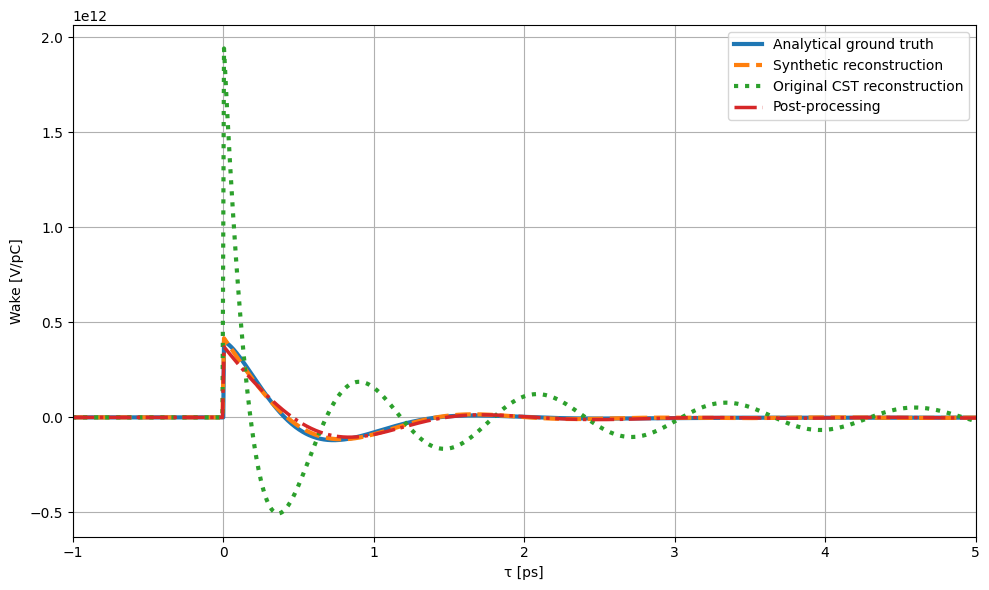

Loaded CST file: /home/kim/PCWR/data/ss_p02_cpw13p99.txt
Detected s-unit: mm
Conversion: 1 mm = 0.001 m


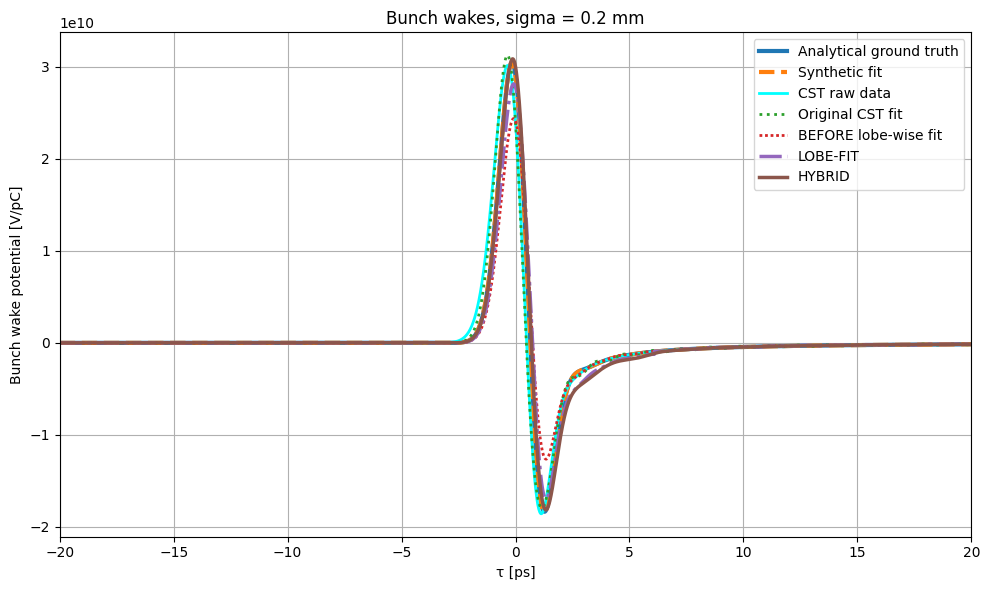

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    t * 1e12,
    W_true,
    linestyle="solid",
    label="Analytical ground truth",
    linewidth=3,
)

plt.plot(
    t * 1e12,
    W_rec_syn,
    linestyle="dashed",
    label="Synthetic reconstruction",
    linewidth=3,
)

plt.plot(
    t * 1e12,
    W_rec_cst,
    linestyle="dotted",
    label="Original CST reconstruction",
    linewidth=3,
)

# plt.plot(
#     t * 1e12,
#     W_cst_cut_unscaled,
#     linestyle=(0, (1, 1)),
#     label=f"BEFORE lobe-wise fit: CST wake from max-envelope Re[Z], f <= {cst_cutoff_THz:.3f} THz",
#     linewidth=2,
# )

# plt.plot(
#     t * 1e12,
#     W_cst_cut,
#     linestyle="dashdot",
#     label=f"Unscaled cutoff seed wake from max-envelope Re[Z], f <= {cst_cutoff_THz:.3f} THz",
#     linewidth=2,
# )

# plt.plot(
#     t * 1e12,
#     W_rec_cst_from_cut_input,
#     linestyle=(0, (3, 1, 1, 1)),
#     label="Reconstructed from lobe-wise fitted cutoff bunch wake",
#     linewidth=2,
# )

plt.plot(
    t * 1e12,
    W_cst_hybrid,
    linestyle="dashdot",
    label="Post-processing",
    linewidth=2.5,
)

plt.xlim(-1, 5)
plt.xlabel("τ [ps]")
plt.ylabel("Wake [V/pC]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

for i, (path, sigma) in enumerate(zip(paths, sigmas)):
    t_raw, w_raw = load_cst(path)

    plt.figure(figsize=(10, 6))

    plt.plot(
        t*1e12,
        V_list_syn[i],
        lw=3,
        label="Analytical ground truth",
    )

    plt.plot(
        t*1e12,
        V_fit_syn_list[i],
        "--",
        lw=3,
        label="Synthetic fit",
    )

    plt.plot(
        t_raw*1e12,
        w_raw,
        lw=2,
        color="cyan",
        label="CST raw data",
    )

    plt.plot(
        t*1e12,
        V_fit_cst_list[i],
        ":",
        lw=2,
        label="Original CST fit",
    )

    plt.plot(
        t*1e12,
        V_list_cst_cut_input_unscaled[i],
        linestyle=(0, (1, 1)),
        lw=2,
        label=f"BEFORE lobe-wise fit",
    )

    plt.plot(
        t*1e12,
        V_list_cst_cut_input[i],
        "-.",
        lw=2.5,
        label=f"LOBE-FIT",
    )

    plt.plot(
        t*1e12,
        V_list_cst_hybrid[i],
        linestyle="solid",
        lw=2.5,
        label="HYBRID",
    )

    # plt.plot(
    #     t*1e12,
    #     V_fit_cst_from_cut_input_list[i],
    #     linestyle=(0, (3, 1, 1, 1)),
    #     lw=2,
    #     label="Fit to lobe-wise",
    # )

    plt.xlabel("τ [ps]")
    plt.ylabel("Bunch wake potential [V/pC]")
    plt.title(f"Bunch wakes, sigma = {sigma*c_light*1e3:.1f} mm")
    plt.grid()
    plt.xlim(-20, 20)
    plt.legend()
    plt.tight_layout()
    plt.show()